# Multi-Stage Attack Detection Using Random Forest (Baseline v3.1)

## Fix dari v3:
- Stage 2 F1 anjlok karena IP-split menempatkan **semua** password & mitm di test
  (0 di train → model gak pernah lihat → classify Other)
- Train Stage 2 cuma dari **2 src_ip** → gak generalize

## Solusi: **Type-Aware IP Split**
- Untuk setiap **attack type**, pastikan ada IP di train DAN test
- Ini menjamin setiap jenis serangan terwakili di kedua set
- Baru setelah itu, volume-based whale filtering seperti v2

# SETUP

---
## 0. Imports

In [108]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support
)
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier


warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & Prepare

In [109]:
df = pd.read_csv('train_test_network.csv')
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df['dst_port'] = pd.to_numeric(df['dst_port'], errors='coerce').fillna(0)
df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

STAGE_MAP = {
    'normal': 0, 'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}
df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print(f"Shape: {df.shape}")
print(f"\nStage: {df['stage'].value_counts().sort_index().to_dict()}")
print(f"Types: {df['type'].value_counts().to_dict()}")


Shape: (170591, 48)

Stage: {0: 96395, 1: 23702, 2: 49469, 3: 1025}
Types: {'normal': 96395, 'scanning': 23702, 'injection': 16310, 'xss': 15231, 'dos': 14547, 'ddos': 2047, 'password': 1034, 'ransomware': 886, 'mitm': 300, 'backdoor': 139}


---
### Attack Chain Analysis

In [110]:
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())
print(f"Dst IPs: S1={len(dst_s1)} | S2={len(dst_s2)} | S3={len(dst_s3)}")
print(f"S1∩S2={len(dst_s1&dst_s2)} | S1∩S2∩S3={len(dst_s1&dst_s2&dst_s3)}")

rows = []
for ip in sorted(dst_s1 | dst_s2 | dst_s3):
    s1=len(df[(df['dst_ip']==ip)&(df['stage']==1)])
    s2=len(df[(df['dst_ip']==ip)&(df['stage']==2)])
    s3=len(df[(df['dst_ip']==ip)&(df['stage']==3)])
    if s1>0 or s3>0: rows.append({'dst_ip':ip,'S1':s1,'S2':s2,'S3':s3})
print(f"\nKey targets:")
print(pd.DataFrame(rows).sort_values('S3',ascending=False).head(15).to_string(index=False))

Dst IPs: S1=46 | S2=161 | S3=13
S1∩S2=38 | S1∩S2∩S3=5

Key targets:
         dst_ip  S1  S2  S3
  192.168.1.193 200 128 508
   192.168.1.33 200   0 335
     121.0.0.42   0   0  49
  103.38.120.36   0  23  48
  34.230.157.88   1   9  26
    192.168.1.1 200 300  18
   192.168.1.37   0   0   9
    13.55.50.68   0   0   9
  52.11.124.117   1  14   8
  203.14.129.10   0   0   5
  34.236.82.205   0   5   4
192.168.159.152   0  24   4
    192.168.1.6   2   7   2
  117.18.237.29  23  69   0
  101.119.11.17  68 285   0


In [111]:
len(df[df['stage'] == 3]['dst_ip'].unique())

13

### Check stage timestamps

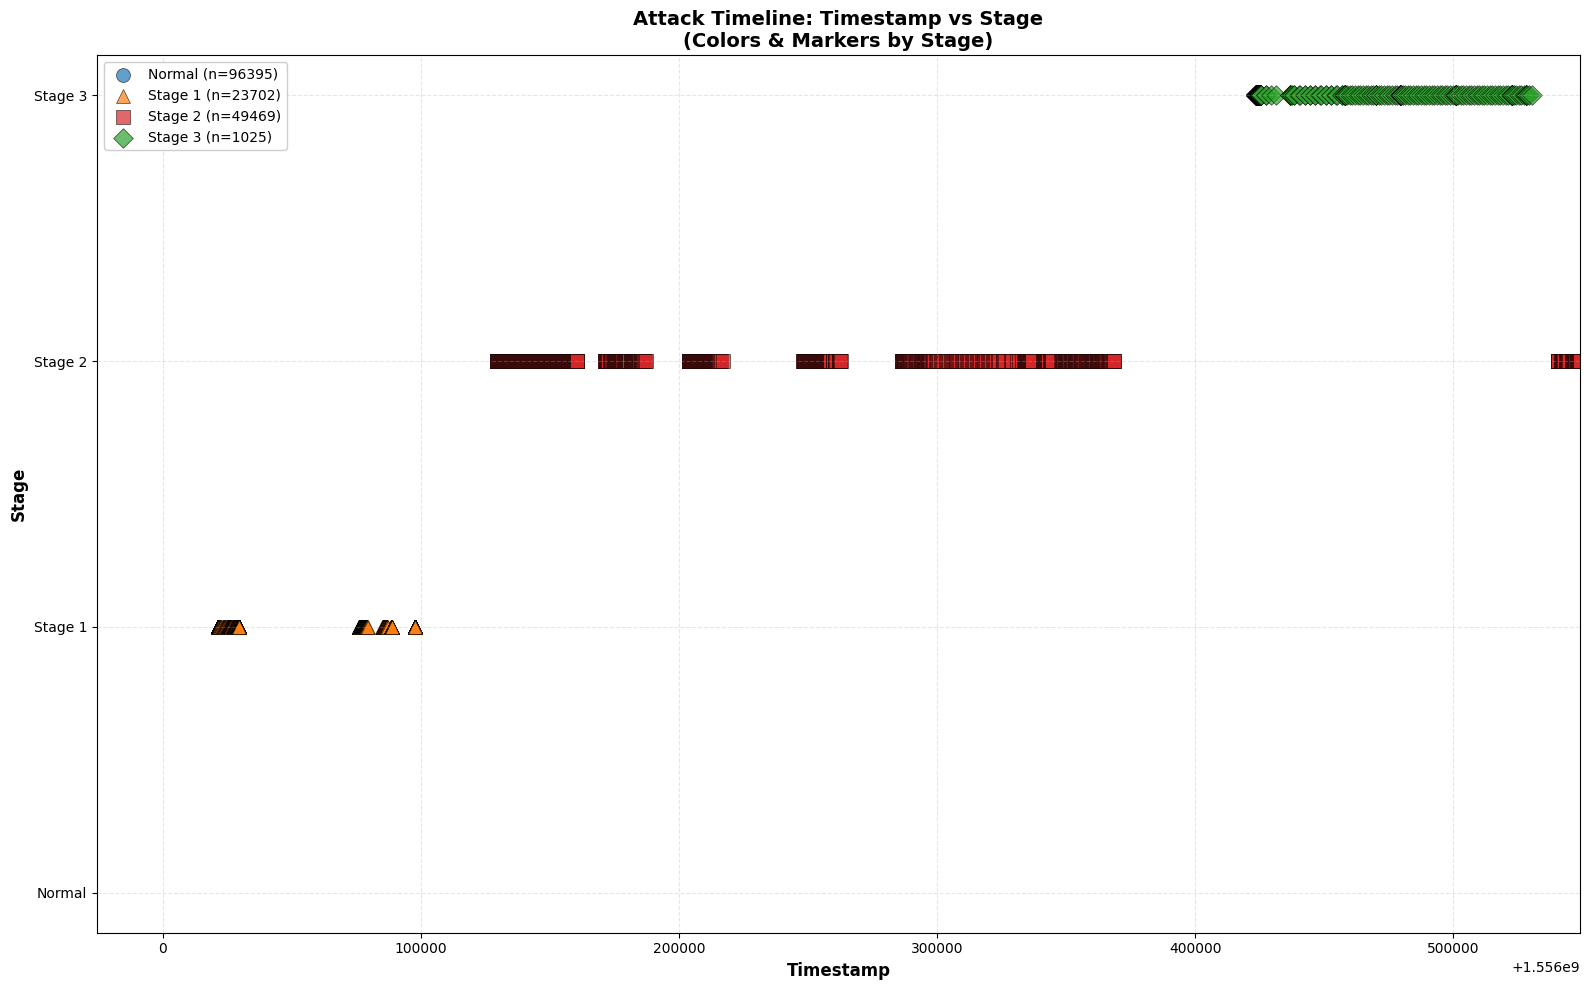


Visualization Summary:
  Total events: 170591
  Timestamp range: 1554198358 to 1556549129
  Display range: 1555974395 to 1556549129
  Stage distribution:
    Normal:  96395 ( 56.5%)
    Stage 1:  23702 ( 13.9%)
    Stage 2:  49469 ( 29.0%)
    Stage 3:   1025 (  0.6%)


In [112]:
# Temporal-Stage Dot Graph: Timestamp vs Stage (marked & colored by Stage)
df_plot = df.dropna(subset=['ts']).copy()

# Map stages to colors, markers, and names
stage_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}  # blue, orange, red, green
stage_names = {0: 'Normal', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}  # circle, triangle, square, diamond

# Find timestamp limits: start just before first non-normal stage
first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
ts_margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02  # 2% margin
ts_start = first_stage_ts - ts_margin if first_stage_ts else df_plot['ts'].min()
ts_end = df_plot['ts'].max()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Plot each stage separately for legend
for stage in sorted(df_plot['stage'].unique()):
    stage_data = df_plot[df_plot['stage'] == stage]
    ax.scatter(stage_data['ts'], stage_data['stage'], 
               c=stage_colors[stage], 
               marker=stage_markers[stage],
               s=100, alpha=0.7, 
               label=f'{stage_names[stage]} (n={len(stage_data)})',
               edgecolors='black', linewidth=0.5)

# Configure axes
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Stage', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Stage\n(Colors & Markers by Stage)', 
             fontsize=14, fontweight='bold')

# Set Y-axis ticks and labels to stages
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([stage_names[s] for s in [0, 1, 2, 3]])

# Set X-axis limits
ax.set_xlim(ts_start, ts_end)

# Format X-axis
ax.ticklabel_format(style='plain', axis='x')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig('timeline_stage_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization Summary:")
print(f"  Total events: {len(df_plot)}")
print(f"  Timestamp range: {df_plot['ts'].min():.0f} to {df_plot['ts'].max():.0f}")
print(f"  Display range: {ts_start:.0f} to {ts_end:.0f}")
print(f"  Stage distribution:")
for s in [0, 1, 2, 3]:
    count = (df_plot['stage'] == s).sum()
    pct = 100 * count / len(df_plot)
    print(f"    {stage_names[s]}: {count:>6} ({pct:>5.1f}%)")

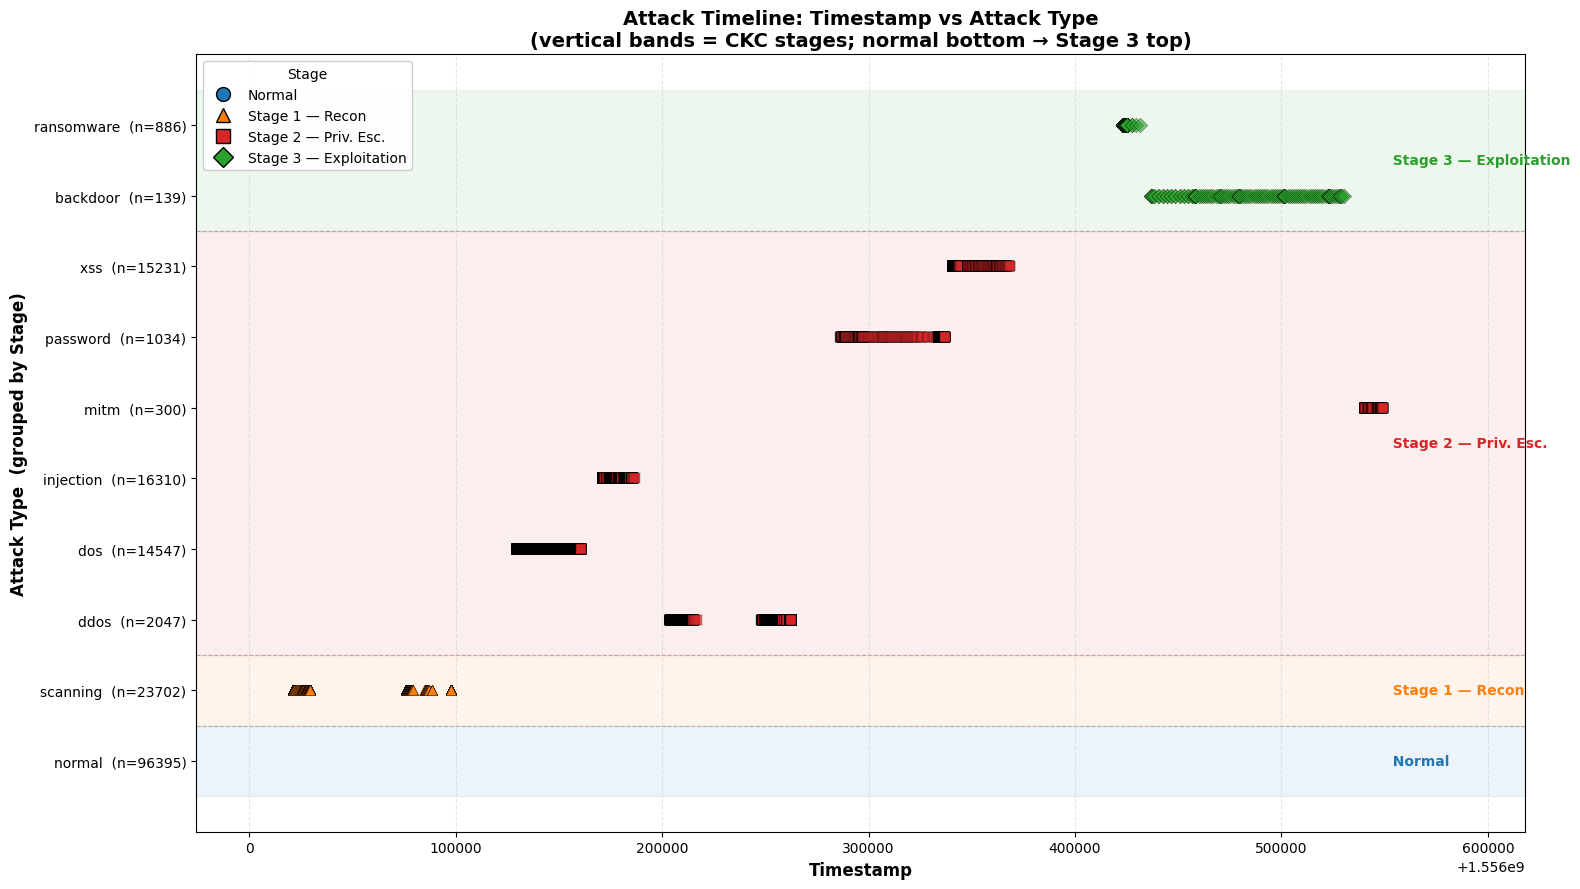

In [113]:
# Temporal-Stage Dot Graph: Timestamp vs Attack TYPE, grouped into Stage bands
df_plot = df.dropna(subset=['ts']).copy()

stage_colors  = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}
stage_names   = {0: 'Normal', 1: 'Stage 1 — Recon', 2: 'Stage 2 — Priv. Esc.', 3: 'Stage 3 — Exploitation'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}

# --- order attack types by stage (normal bottom → stage 3 top) ---
TYPE_STAGE = {t: df_plot.loc[df_plot['type'] == t, 'stage'].iloc[0] for t in df_plot['type'].unique()}
types_by_stage = {s: sorted([t for t, st in TYPE_STAGE.items() if st == s]) for s in [0, 1, 2, 3]}
y_order = []                      # bottom → top
for s in [0, 1, 2, 3]:
    y_order.extend(types_by_stage[s])
ypos = {t: i for i, t in enumerate(y_order)}

SHOW_NORMAL_CLUSTER = False       # True = include the far-left normal cluster in view

first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02
ts_start = (df_plot['ts'].min() if SHOW_NORMAL_CLUSTER
            else (first_stage_ts - margin if pd.notna(first_stage_ts) else df_plot['ts'].min()))
ts_end = df_plot['ts'].max()

fig, ax = plt.subplots(figsize=(16, 9))

# --- shaded horizontal bands per stage + right-side label + separators ---
for s in [0, 1, 2, 3]:
    ys = [ypos[t] for t in types_by_stage[s]]
    if not ys:
        continue
    lo, hi = min(ys) - 0.5, max(ys) + 0.5
    ax.axhspan(lo, hi, color=stage_colors[s], alpha=0.08, zorder=0)
    ax.text(ts_end, (lo + hi) / 2, f'  {stage_names[s]}', va='center', ha='left',
            fontsize=10, fontweight='bold', color=stage_colors[s])
    if s > 0:
        ax.axhline(lo, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)

# --- plot points: y = type, color/marker = stage ---
for s in [0, 1, 2, 3]:
    for t in types_by_stage[s]:
        d = df_plot[df_plot['type'] == t]
        ax.scatter(d['ts'], [ypos[t]] * len(d), c=stage_colors[s], marker=stage_markers[s],
                   s=55, alpha=0.6, edgecolors='black', linewidth=0.3, zorder=3)

ax.set_yticks(range(len(y_order)))
ax.set_yticklabels([f'{t}  (n={(df_plot["type"] == t).sum()})' for t in y_order], fontsize=10)
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Attack Type  (grouped by Stage)', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Attack Type\n(vertical bands = CKC stages; normal bottom → Stage 3 top)',
             fontsize=14, fontweight='bold')
ax.ticklabel_format(style='plain', axis='x')
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

handles = [plt.Line2D([0], [0], marker=stage_markers[s], color='w', markerfacecolor=stage_colors[s],
                      markeredgecolor='black', markersize=10, label=stage_names[s]) for s in [0, 1, 2, 3]]
ax.legend(handles=handles, loc='upper left', fontsize=10, framealpha=0.95, title='Stage')

# right margin so the band labels fit
ax.set_xlim(ts_start, ts_end + (ts_end - ts_start) * 0.12)

plt.tight_layout()
plt.savefig('timeline_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. DATA  PREPROCESSING

### 2.1. Feature Engineering

*Notes: Some future / test IP information can get into the dataset, however it is okay because :
    - in actual implementation, every new flow will update model's information, thus leading to the newest attributes being taken into account


═══════════════════════════════════════════════════════════════════════════
NEW FLOW-LEVEL FEATURES  — drop-in replacement for the feature block in Cell 15
═══════════════════════════════════════════════════════════════════════════
These follow the MECE framework:
    Bucket 1 — Scan behavior   (Stage 1 signal): breadth of contact
    Bucket 2 — Exploit behavior(Stage 2 signal): per-flow / windowed anomaly

- All features are computed in feature_engineering() BEFORE the pre-split drop, so they only use raw columns (src_ip, ts, dst_ip, service, conn_state, src_bytes, dst_bytes, dst_pkts). Output columns are new names, so nothing in DROP_COLS_PRESPLIT / DROP_COLS_AFTERSPLIT touches them, and get_dummies leaves them alone (numeric). aggregate_by_dst_ip() will roll them up to Stage 3 for free. → NO pipeline changes required.

- No Future Data leakage, because all functions either:
    1. Does not require cross-row data hence will not use any information other than an isolated row to calculate the new feature for that row
    2. Use historical cross-row data, for example: if row is at time t, then the used rows will be [t-x : t]
═══════════════════════════════════════════════════════════════════════════

In [114]:
ABNORMAL_CONN_STATES = {
    'S0', 'REJ', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH', 'SH', 'SHR', 'OTH',
    'S1', 'S2', 'S3',
}



# ── BUCKET 1: SCAN BEHAVIOR ──────────────────────────────────────────────────

def dst_ip_fanout_10s(df):
    """IP fanout: number of unique dst_ip a src_ip contacts in a 10s window.
    High fanout = horizontal scanning across hosts (ATT&CK T1595/T1018)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_ip']):
        ret['dst_ip_fanout_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'dst_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    # HACK ANTI-STRING: factorize IP strings to int codes so rolling stays fast
    temp['dst_ip_code'] = pd.factorize(temp['dst_ip'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    fanout = temp.groupby('src_ip', sort=False)['dst_ip_code'].rolling('10s').apply(lambda x: len(set(x)), raw=False)
    temp['val'] = fanout.values
    ret['dst_ip_fanout_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def no_response_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window that got no response back
    (dst_bytes == 0 AND dst_pkts == 0). High ratio = blind probing (T1595)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_bytes', 'dst_pkts']):
        ret['no_response_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    # per-flow no-response indicator
    temp['no_resp'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['no_resp'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['no_response_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def service_entropy_10s(df):
    """Shannon entropy (bits) of the services a src_ip touches in a 10s window.
    High entropy = sweeping many services = service discovery (T1046)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'service']):
        ret['service_entropy_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'service']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['service_code'] = pd.factorize(temp['service'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    def _entropy(x):
        p = pd.Series(x).value_counts(normalize=True)
        return float(-(p * np.log2(p)).sum())

    ent = temp.groupby('src_ip', sort=False)['service_code'].rolling('10s').apply(_entropy, raw=False)
    temp['val'] = ent.values
    ret['service_entropy_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret

def is_no_response(df):
    ret = df.copy()
    ret['is_no_response'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int)
    return ret

def is_rej_udp(df):
    ret = df.copy()
    ret['is_rej_udp'] = (
        (ret['conn_state'] == 'REJ') & (ret['proto'] == 'udp')
    ).astype(int)
    return ret

# def is_abnormal_conn(df):
#     ret = df.copy()
#     ret['is_abnormal_conn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int)
#     return ret

# ── BUCKET 2: EXPLOIT BEHAVIOR ───────────────────────────────────────────────

def bytes_ratio(df):
    """Payload asymmetry per flow: src_bytes / (dst_bytes + 1).
    >> 1 = pushing a payload (injection/exploit, T1190); ~0 = pulling data."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['src_bytes', 'dst_bytes']):
        ret['bytes_ratio'] = 0.0
        return ret

    s = pd.to_numeric(ret['src_bytes'], errors='coerce').fillna(0)  # src_bytes has mixed types
    d = pd.to_numeric(ret['dst_bytes'], errors='coerce').fillna(0)
    ret['bytes_ratio'] = (s / (d + 1.0)).astype(float)
    return ret

# def bytes_per_pkt_src(df):
#     """Mean outbound packet size: src_bytes / (src_pkts + 1). Tiny = scan/flood,
#     large = exploit payload. Division — trees can't derive it from the columns."""
#     ret = df.copy()
#     s = pd.to_numeric(ret.get('src_bytes', 0), errors='coerce').fillna(0)
#     p = pd.to_numeric(ret.get('src_pkts', 0), errors='coerce').fillna(0)
#     ret['bytes_per_pkt_src'] = (s / (p + 1.0)).astype(float)
#     return ret
def abnormal_conn_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window ending in an abnormal
    conn_state (REJ/RSTO/S0/OTH/...). High ratio = aborted/abused handshakes
    typical of exploit attempts and DoS (T1190/T1499)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'conn_state']):
        ret['abnormal_conn_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['abn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['abn'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['abnormal_conn_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def burst_ratio_10s(df):
    """Burstiness: (conns in last 1s) / (conns in last 10s) for a src_ip.
    ~1.0 = all traffic crammed into a 1s spike = flooding (DoS/DDoS, T1498)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip']):
        ret['burst_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    g = temp.groupby('src_ip', sort=False)['ts']
    c1 = g.rolling('1s').count().values
    c10 = g.rolling('10s').count().values
    temp['val'] = c1 / (c10 + 1e-9)
    ret['burst_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret

def conn_count_10s(df):
    ret = df.copy()
    if 'ts' not in ret.columns or 'src_ip' not in ret.columns:
        ret['conn_count_10s'] = 0.0
        return ret
    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')
    counts = temp.groupby('src_ip', sort=False)['ts'].rolling('10s').count()
    temp['val'] = counts.values
    ret['conn_count_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def dst_port_fanout_10s(df):
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_port']):
        ret['dst_port_fanout_10s'] = 0.0
        return ret
    temp = ret[['ts', 'src_ip', 'dst_port']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['dst_port_code'] = pd.factorize(temp['dst_port'])[0]
    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')
    fanout = temp.groupby('src_ip', sort=False)['dst_port_code'].rolling('10s').apply(lambda x: len(set(x)), raw=False)
    temp['val'] = fanout.values
    ret['dst_port_fanout_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret



############  Function to call  ##############

def feature_engineering(df):
    ret = df.copy()

    # Bucket 1: scan behavior
    ret = is_no_response(ret)
    ret = is_rej_udp(ret)
    ret = dst_ip_fanout_10s(ret)
    ret = dst_port_fanout_10s(ret)   # ← balikin
    ret = conn_count_10s(ret)        # ← balikin
    ret = no_response_ratio_10s(ret)
    ret = service_entropy_10s(ret)

    # Bucket 2: exploit behavior
    ret = bytes_ratio(ret)
    ret = abnormal_conn_ratio_10s(ret)
    ret = burst_ratio_10s(ret)

    return ret


def get_dummies (df):
    ret = df.copy()
    # Identify categorical columns (exclude src_ip, dst_ip, stage, and numeric columns)
    categorical_cols = [c for c in ret.columns 
                       if ret[c].dtype == 'object' and c not in ['src_ip', 'dst_ip', 'stage', 'type', 'label']]
    
    # One-hot encode only the categorical columns, preserving IPs
    if categorical_cols:
        ret = pd.get_dummies(ret, columns=categorical_cols, drop_first=True, dtype=int)
    
    return ret


### 2.2. Feature Selection

In [115]:
DROP_COLS_PRESPLIT = [ 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'http_referrer', 'sequence_type',
    'src_ip_bytes',
]
remaining = [c for c in df.columns if c not in DROP_COLS_PRESPLIT]
print(f"Presplit Features ({len(remaining)}): {remaining}")

DROP_COLS_AFTERSPLIT = [
    # Presplit features
    'src_ip', 'ts',    
    
    # label derivatives
    'type', 'label'
    ]

rem = [c for c in df.columns if c not in DROP_COLS_AFTERSPLIT and c not in DROP_COLS_PRESPLIT]
print(f"After-split Features ({len(rem)}): {rem}") 


Presplit Features (19): ['ts', 'src_ip', 'dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'label', 'type', 'stage']
After-split Features (15): ['dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'stage']


In [116]:

def feature_selection_presplit (df, drop_cols=DROP_COLS_PRESPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

def feature_selection_aftersplit (df, drop_cols=DROP_COLS_AFTERSPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

## 3. DATA SPLITTING

### 3.1. TIME SPLITTING WITH FLOW-AWARE SPLIT


In [117]:
def timesplit(df):
    df_temporal = df.dropna(subset=['ts']).copy()
    # cutoff di ONSET S3 (flow S3 pertama), bukan median.
    # past = murni precursor (0 flow S3), future = seluruh burst eskalasi.
    cutoff = df_temporal.loc[df_temporal['stage'] == 3, 'ts'].min()
    df_past   = df_temporal[df_temporal['ts'] <  cutoff].copy()
    df_future = df_temporal[df_temporal['ts'] >= cutoff].copy()
    print(f"Cutoff (S3 onset): {cutoff:.0f}")
    print(f"df_past rows     : {len(df_past)}")
    print(f"df_future rows   : {len(df_future)}")
    print(f"Stage 3 in past  : {(df_past['stage'] == 3).sum()}   (harus 0)")
    print(f"Stage 3 in future: {(df_future['stage'] == 3).sum()}")
    return df_past, df_future

---
### 3.2. Type-Aware IP Split (NEW)

Problem v2/v3:
IP split per-stage bisa menempatkan seluruh attack type di satu set:
- Train Stage 2: 2 IP → hanya injection, xss, dos, ddos
- Test Stage 2: 10 IP → password, mitm, dll → **gak pernah dilihat model**

Solusi:
Split per **attack type**, bukan per stage:
1. Untuk setiap unique `type`, kumpulkan semua `src_ip` yang melakukannya
2. Untuk setiap type, pastikan minimal 1 IP masuk test DAN sisanya di train
3. IP "whale" (>30% rows dari type itu) wajib train
4. Ini menjamin SETIAP attack type ada di train DAN test

In [118]:
def type_aware_ip_split(df, test_ratio=0.3, normal_test_ratio = 0.2, test_ratio_stage_3 = 0.5, random_state=42, verbose=True):
    """
    Type-Aware IP Split: Ensures every attack type is represented in both train and test.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with columns: 'src_ip', 'type', 'stage'
    test_ratio : float
        Target ratio of flows in test set (default 0.3)
    normal_test_ratio : float
        Target ratio of normal flows in test set (default 0.2)
    test_ratio_stage_3 : float
        Target ratio of flows in test set for stage 3 (default 0.5)
    random_state : int
        Random seed for reproducibility (default 42)
    verbose : bool
        Print detailed split information (default True)
    
    Returns:
    --------
    df_train, df_test : DataFrames
        Train and test splits with no overlapping IPs
    """
    rng = np.random.RandomState(random_state)
    test_ips = set()
    train_ips = set()

    if verbose:
        print("=" * 60)
        print("TYPE-AWARE IP SPLIT")
        print("=" * 60)

    # ── Step 1: Per attack type, split IPs ──────────────────────
    attack_types = [t for t in df['type'].unique() if t != 'normal']

    for atype in sorted(attack_types):
        type_df = df[df['type'] == atype]
        type_total = len(type_df)
        target_test = int(test_ratio * type_total)
        ip_counts = type_df['src_ip'].value_counts().reset_index()
        ip_counts.columns = ['src_ip', 'flow_count']
        # if atype in ['backdoor', 'ransomware']:
        #     target_test = int(test_ratio_stage_3 * type_total)
        #     selected_s3_ips.append(type_df['src_ip'].unique()[:target_test//2])
        #     test_ips.update(selected_s3_ips[-1])
        if atype in ['backdoor', 'ransomware']:
            target_test = int(test_ratio_stage_3 * type_total)
            cur = 0; selected = []
            for _, row in ip_counts.iterrows():  # ip_counts already sorted descending by flow_count
                selected.append(row['src_ip'])
                cur += row['flow_count']
                if cur >= target_test:
                    break
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | "
                    f"Test IPs: {len(selected)} ({cur} flows)")        
        
        if atype not in ['backdoor', 'ransomware']:
            # Whale filtering: IP dengan >30% dari type ini → wajib train
            whale_threshold = 0.3 * type_total
            whales = ip_counts[ip_counts['flow_count'] > whale_threshold]
            small_fish = ip_counts[ip_counts['flow_count'] <= whale_threshold]
            
            # Whale IPs → train
            for wip in whales['src_ip']:
                train_ips.add(wip)
            
            # Dari small fish, pilih IPs untuk test
            shuffled = small_fish.sample(frac=1, random_state=rng).reset_index(drop=True)
            cur = 0; selected = []
            for _, row in shuffled.iterrows():
                if row['src_ip'] in train_ips:
                    continue
                if cur + row['flow_count'] <= target_test:
                    selected.append(row['src_ip'])
                    cur += row['flow_count']
                if cur >= target_test:
                    break
            
            # Fallback: kalau gak ada yang terpilih, ambil 1 small fish terkecil
            if not selected and len(small_fish) > 0:
                for _, row in small_fish.sort_values('flow_count').iterrows():
                    if row['src_ip'] not in train_ips:
                        selected.append(row['src_ip'])
                        cur += row['flow_count']
                        break
            
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | Whales: {len(whales)} | "
                    f"Test IPs: {len(selected)} ({cur} flows)")

    # ── Step 2: Normal-only IPs ─────────────────────────────────
    all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
    pure_normal = df[(df['stage'] == 0) & (~df['src_ip'].isin(all_attack_ips))]
    normal_target = int(normal_test_ratio * len(pure_normal))

    nip = pure_normal['src_ip'].value_counts().reset_index()
    nip.columns = ['src_ip', 'flow_count']
    sn = nip[nip['flow_count'] <= normal_target].sample(frac=1, random_state=rng)
    c = 0; sel_n = []
    for _, row in sn.iterrows():
        if c + row['flow_count'] <= normal_target:
            sel_n.append(row['src_ip']); c += row['flow_count']
        if c >= normal_target: break
    test_ips.update(sel_n)
    if verbose:
        print(f"  {'normal':12s}: {len(pure_normal):>6} flows | Test IPs: {len(sel_n)} ({c} flows)")

    # ── Step 3: Enforce no-overlap ──────────────────────────────
    test_ips -= train_ips

    # ── Step 4: Split ───────────────────────────────────────────
    df_train = df[~df['src_ip'].isin(test_ips)].copy()
    df_test = df[df['src_ip'].isin(test_ips)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} ({df_train['src_ip'].nunique()} IPs)")
        print(f"Test:  {len(df_test)} ({df_test['src_ip'].nunique()} IPs)")
        print(f"IP overlap: {len(set(df_train['src_ip']) & set(df_test['src_ip']))}")

        # ── Validation: every type in both sets ─────────────────────
        print(f"\nType coverage validation:")
        all_ok = True
        for atype in sorted(attack_types):
            in_train = len(df_train[df_train['type'] == atype])
            in_test = len(df_test[df_test['type'] == atype])
            status = "OK" if (in_train > 0 and in_test > 0) else "MISSING!"
            if in_train == 0 or in_test == 0:
                all_ok = False
            print(f"  {atype:12s}: train={in_train:>6}, test={in_test:>5}  [{status}]")

        if all_ok:
            print("\n  ALL TYPES present in both train and test!")
        else:
            print("\n  WARNING: Some types missing from train or test")

        print(f"\nStage distribution:")
        for s in [0, 1, 2, 3]:
            tr = (df_train['stage']==s).sum(); te = (df_test['stage']==s).sum()
            print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

    return df_train, df_test

---
# DATA PIPELINE

## 4. PIPELINE EXECUTION

In [119]:
df.columns

Index(['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_referrer', 'http_version',
       'http_request_body_len', 'http_response_body_len', 'http_status_code',
       'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types',
       'weird_name', 'weird_addl', 'weird_notice', 'label', 'type', 'stage',
       'sequence_type'],
      dtype='object')

### 4.1. Initial Pipeline Execution

In [120]:
# Data Preprocessing
df = feature_engineering(df)
df = feature_selection_presplit(df)
df = get_dummies(df)

# Execute Time Split
df_past , df_future = timesplit(df)

# Execute IP Split
df_train_past, df_test_past = type_aware_ip_split(df_past, test_ratio=0.3, test_ratio_stage_3=0.5, random_state=42, verbose=True)

# Snapshot lengkap (sebelum src_ip/ts dibuang) khusus buat tabel entity
df_past_full, df_future_full = df_past.copy(), df_future.copy()

Cutoff (S3 onset): 1556423390
df_past rows     : 169266
df_future rows   : 1325
Stage 3 in past  : 0   (harus 0)
Stage 3 in future: 1025
TYPE-AWARE IP SPLIT
  ddos        :   2047 flows | Whales: 1 | Test IPs: 5 (469 flows)
  dos         :  14547 flows | Whales: 1 | Test IPs: 2 (1728 flows)
  injection   :  16310 flows | Whales: 1 | Test IPs: 7 (982 flows)
  password    :   1034 flows | Whales: 2 | Test IPs: 3 (105 flows)
  scanning    :  23702 flows | Whales: 1 | Test IPs: 17 (4930 flows)
  xss         :  15231 flows | Whales: 1 | Test IPs: 2 (6 flows)
  normal      :  83683 flows | Test IPs: 27 (16736 flows)

Train: 141695 (38 IPs)
Test:  27571 (46 IPs)
IP overlap: 0

Type coverage validation:
  ddos        : train=  1767, test=  280  [OK]
  dos         : train= 12819, test= 1728  [OK]
  injection   : train= 15336, test=  974  [OK]
  password    : train=   929, test=  105  [OK]
  scanning    : train= 18772, test= 4930  [OK]
  xss         : train= 15225, test=    6  [OK]

  ALL TYPES 

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

### 4.1.5. ENTITY-LEVEL FEATURE CREATION

DECLARE TABLE FOR ENTITY-LEVEL FEATURE CREATION:
1. Entity-level features are created here before feature_selection_aftersplit because it requires:
    - *Presplit features*: 'src_ip', 'ts', 'dst_ip', 'stage'


In [121]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ENTITY-LEVEL  (replaces Cell 34)
# ════════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# TIME-FREE ENTITY-LEVEL FEATURES (v4.3) — same structure as flow-level:
#   one function per feature, threaded through a wrapper (ret = feature(df, ret)).
# Entity features read from the flow frame (df_flow) and accumulate into a
# per-dst_ip frame (ret); only the features aggregate_by_dst_ip CANNOT make are
# here. DROPPED vs v4.2: all ts features and all label-reading (`stage`) features.
# ═══════════════════════════════════════════════════════════════════════════
 
#### EF RAW

def _gini(x):
    a = np.asarray(x, dtype=float)
    if a.size == 0 or a.sum() == 0:
        return 0.0
    a = np.sort(a); n = a.size; idx = np.arange(1, n + 1)
    return float((2.0 * (idx * a).sum()) / (n * a.sum()) - (n + 1.0) / n)
  
 
# ── Bucket 1: Topology / convergence (from RAW cols — needs src_ip) ───────────
def ef_n_unique_src(df_flow):
    """Fan-in: # unique src_ip hitting each dst_ip (DDoS / coordinated, T1498)."""
    return df_flow.groupby('dst_ip')['src_ip'].nunique()
 
def ef_src_gini(df_flow):
    """Source concentration. ~1 = single persistent actor (backdoor/ransomware);
    ~0 = many evenly-spread sources (flood)."""
    return df_flow.groupby('dst_ip')['src_ip'].apply(
        lambda s: _gini(s.value_counts().values))


#### EF PROBAB
 
# ── Bucket 4: Kill-chain evidence (from attached probas) ──────────────────────
def ef_kill_chain_score(df_enriched):
    """MIN of the two detector peaks — high only if the victim saw BOTH recon AND
    exploit evidence. Time-free, label-free; replaces ef_reached_s*/ef_s1_before_s2.
    (Per-detector max/mean/std come free from aggregate_by_dst_ip.)"""
    g = df_enriched.groupby('dst_ip')
    max_s1 = g['stage_1_proba'].max()
    max_s2 = g['stage_2_proba'].max()
    return np.minimum(max_s1, max_s2)

def ef_kill_chain_progression(df_enriched):
    """Feature engineering for kill-chain progression."""
    g = df_enriched.groupby('dst_ip')
    max_s1 = g['stage_1_proba'].max()
    max_s2 = g['stage_2_proba'].max()
    return ((max_s1 + max_s2) // 2).fillna(0).astype(int)  # 0=none, 1=one stage, 2=both stages )




In [122]:
# ── Wrappers (mirror feature_engineering): ret = feature(df, ret) ─────────────
def entity_features_raw(df_flow):
    """Call BEFORE feature_selection_aftersplit (needs src_ip)."""
    assert {'dst_ip', 'src_ip'}.issubset(df_flow.columns), \
        "entity_features_raw needs dst_ip & src_ip — call BEFORE feature_selection_aftersplit"
    g = df_flow.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'

    out['ef_n_unique_src'] = ef_n_unique_src(df_flow)
    out['ef_src_gini'] = ef_src_gini(df_flow)

    return out.fillna(0.0)
 
 
def entity_features_proba(df_enriched):
    """Call AFTER stage_1/2_proba are attached (stage-aware path only)."""
    assert {'dst_ip', 'stage_1_proba', 'stage_2_proba'}.issubset(df_enriched.columns), \
        "entity_features_proba needs stage_1/2_proba — call AFTER proba attach"
    g = df_enriched.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'

    out['ef_kill_chain_score'] = ef_kill_chain_score(df_enriched)
    out['ef_kill_chain_progression'] = ef_kill_chain_progression(df_enriched)
    return out.fillna(0.0)
 

In [123]:
# NEW — entity features from raw cols (src_ip/ts STILL present here)
ef_raw_train = entity_features_raw(df_test_past)   # training entities (from test_past)
ef_raw_test  = entity_features_raw(df_future)      # test entities
print(f"ef_raw_train: {ef_raw_train.shape} | ef_raw_test: {ef_raw_test.shape}")

ef_raw_train: (349, 2) | ef_raw_test: (102, 2)


### 4.2. Final Feature Selection

In [124]:

df_past, df_future = feature_selection_aftersplit(df_past), feature_selection_aftersplit(df_future)
df_train_past, df_test_past = feature_selection_aftersplit(df_train_past), feature_selection_aftersplit(df_test_past)


## Helper Functions

In [125]:

def find_optimal_threshold(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, y_proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-8)
    bi = np.argmax(f1s)
    bt = thresh[bi] if bi < len(thresh) else 0.5
    print(f"  Optimal threshold: {bt:.4f} (F1={f1s[bi]:.4f})")
    fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
    a1.plot(rec,prec,'b-',lw=1.5); a1.set_xlabel('Recall'); a1.set_ylabel('Precision')
    a1.set_title(f'{name} PR Curve'); a1.grid(True,alpha=0.3)
    a2.plot(thresh,f1s[:-1],'g-',lw=1.5)
    a2.axvline(x=bt,color='r',ls='--',alpha=0.7,label=f't={bt:.3f}')
    a2.set_xlabel('Threshold'); a2.set_ylabel('F1'); a2.set_title(f'{name} F1 vs t')
    a2.legend(); a2.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
    return bt, y_proba

def evaluate_stage(y_true, y_pred, name):
    prec,rec,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='binary',zero_division=0)
    cm = confusion_matrix(y_true,y_pred); tn,fp,fn,tp = cm.ravel()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    return {'f1':f1,'precision':prec,'recall':rec,'fpr':fpr,'cm':cm}


print("Functions defined.")

Functions defined.


# DETECTION MODELS

## 5. Prepare Training vs Testing Data for Stage 1 and Stage 2

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

In [126]:
def prepare_Xy(train_data, test_data, stage_num):
    y_train = (train_data['stage'] == stage_num).astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = (test_data['stage'] == stage_num).astype(int)
    train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)
    X_train = train_data.drop(columns=['stage', 'dst_ip'], errors='ignore') 
    X_test = test_data.drop(columns=['stage', 'dst_ip'], errors='ignore')
    return X_train, X_test, y_train, y_test

---
## 6. Stage 1 — Reconnaissance

### 6.1 Random Forest

In [127]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — Random Forest
# ═══════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# 1. Prepare data
X_tr1, X_te1, y_tr1, y_te1 = prepare_Xy(df_train_past, df_test_past, 1)
print(f"Train: {len(X_tr1)} | Test: {len(X_te1)}")

# 2. Train RF
rf_s1 = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
print("Training RF Stage 1...")
rf_s1.fit(X_tr1, y_tr1)

# 3. Evaluate
y_pred_rf_s1 = rf_s1.predict(X_te1)
f1_rf_s1 = f1_score(y_te1, y_pred_rf_s1)
cm_s1 = confusion_matrix(y_te1, y_pred_rf_s1)
fpr_s1 = cm_s1[0, 1] / (cm_s1[0, 0] + cm_s1[0, 1])

results_s1 = {'cm': cm_s1, 'f1': f1_rf_s1, 'fpr': fpr_s1}

print(f"\nRF Stage 1 F1: {f1_rf_s1:.4f}")
print(f"RF Stage 1 FPR: {fpr_s1:.4f}")
print("\n=== RF Stage 1 ===")
print(classification_report(y_te1, y_pred_rf_s1))

Train: 141695 | Test: 27571
Training RF Stage 1...

RF Stage 1 F1: 0.8819
RF Stage 1 FPR: 0.0484

=== RF Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22641
           1       0.81      0.96      0.88      4930

    accuracy                           0.95     27571
   macro avg       0.90      0.96      0.93     27571
weighted avg       0.96      0.95      0.96     27571



### 6.2 XGBoost

In [128]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — XGBoost
# ═══════════════════════════════════════════════════════════

# 1. Sanitize column names (XGBoost gak terima karakter [ ] < >)
def sanitize_columns(df):
    df_clean = df.copy()
    df_clean.columns = [re.sub(r'[\[\]<>]', '_', str(c)) for c in df_clean.columns]
    return df_clean

X_tr1_xgb = sanitize_columns(X_tr1)
X_te1_xgb = sanitize_columns(X_te1)

# 2. Train XGB
scale_pos_weight_s1 = (y_tr1 == 0).sum() / max((y_tr1 == 1).sum(), 1)
xgb_s1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s1,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB Stage 1...")
xgb_s1.fit(X_tr1_xgb, y_tr1)

# 3. Evaluate
y_pred_xgb_s1 = xgb_s1.predict(X_te1_xgb)
f1_xgb_s1 = f1_score(y_te1, y_pred_xgb_s1)

print(f"\nXGB Stage 1 F1: {f1_xgb_s1:.4f}")
print(f"(RF Stage 1 F1: {f1_rf_s1:.4f} — comparison)")
print("\n=== XGB Stage 1 ===")
print(classification_report(y_te1, y_pred_xgb_s1))

Training XGB Stage 1...

XGB Stage 1 F1: 0.8917
(RF Stage 1 F1: 0.8819 — comparison)

=== XGB Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     22641
           1       0.83      0.97      0.89      4930

    accuracy                           0.96     27571
   macro avg       0.91      0.96      0.93     27571
weighted avg       0.96      0.96      0.96     27571



### 6.3 Learning Curve

---
## 7. Stage 2 — Privilege Escalation (full data)

### 7.1 Random Forest

In [129]:
X_tr2,X_te2,y_tr2,y_te2 = prepare_Xy(df_train_past,df_test_past,2)
print(f"Train: {len(X_tr2)} (S2={y_tr2.sum()}) | Test: {len(X_te2)} (S2={y_te2.sum()})")

rf_s2 = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=5, max_features=0.7,
    min_samples_leaf=2,class_weight='balanced',random_state=42,n_jobs=-1)
print("\nTraining..."); rf_s2.fit(X_tr2,y_tr2)
y_p2 = rf_s2.predict(X_te2)

results_s2 = evaluate_stage(y_te2,y_p2,"Stage 2")
print(classification_report(y_te2,y_p2,target_names=['Other','Stage 2']))

Train: 141695 (S2=46076) | Test: 27571 (S2=3093)

Training...

Stage 2
F1=0.8697  Prec=0.9310  Rec=0.8160  FPR=0.0076
TN=24291 FP=187 FN=569 TP=2524
              precision    recall  f1-score   support

       Other       0.98      0.99      0.98     24478
     Stage 2       0.93      0.82      0.87      3093

    accuracy                           0.97     27571
   macro avg       0.95      0.90      0.93     27571
weighted avg       0.97      0.97      0.97     27571



### 7.2 XGBoost

In [130]:
# ═══════════════════════════════════════════════════════════
# STAGE 2 — XGBoost
# ═══════════════════════════════════════════════════════════
X_tr2_xgb = sanitize_columns(X_tr2)
X_te2_xgb = sanitize_columns(X_te2)

scale_pos_weight_s2 = (y_tr2 == 0).sum() / max((y_tr2 == 1).sum(), 1)
xgb_s2 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s2,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB..."); xgb_s2.fit(X_tr2_xgb, y_tr2)
y_p2_xgb = xgb_s2.predict(X_te2_xgb)

results_s2_xgb = evaluate_stage(y_te2, y_p2_xgb, "Stage 2 (XGB)")
print(classification_report(y_te2, y_p2_xgb, target_names=['Other','Stage 2']))

Training XGB...

Stage 2 (XGB)
F1=0.8767  Prec=0.9437  Rec=0.8186  FPR=0.0062
TN=24327 FP=151 FN=561 TP=2532
              precision    recall  f1-score   support

       Other       0.98      0.99      0.99     24478
     Stage 2       0.94      0.82      0.88      3093

    accuracy                           0.97     27571
   macro avg       0.96      0.91      0.93     27571
weighted avg       0.97      0.97      0.97     27571



---
## 8. Confusion Matrices

Confusion matrices for all stages and models

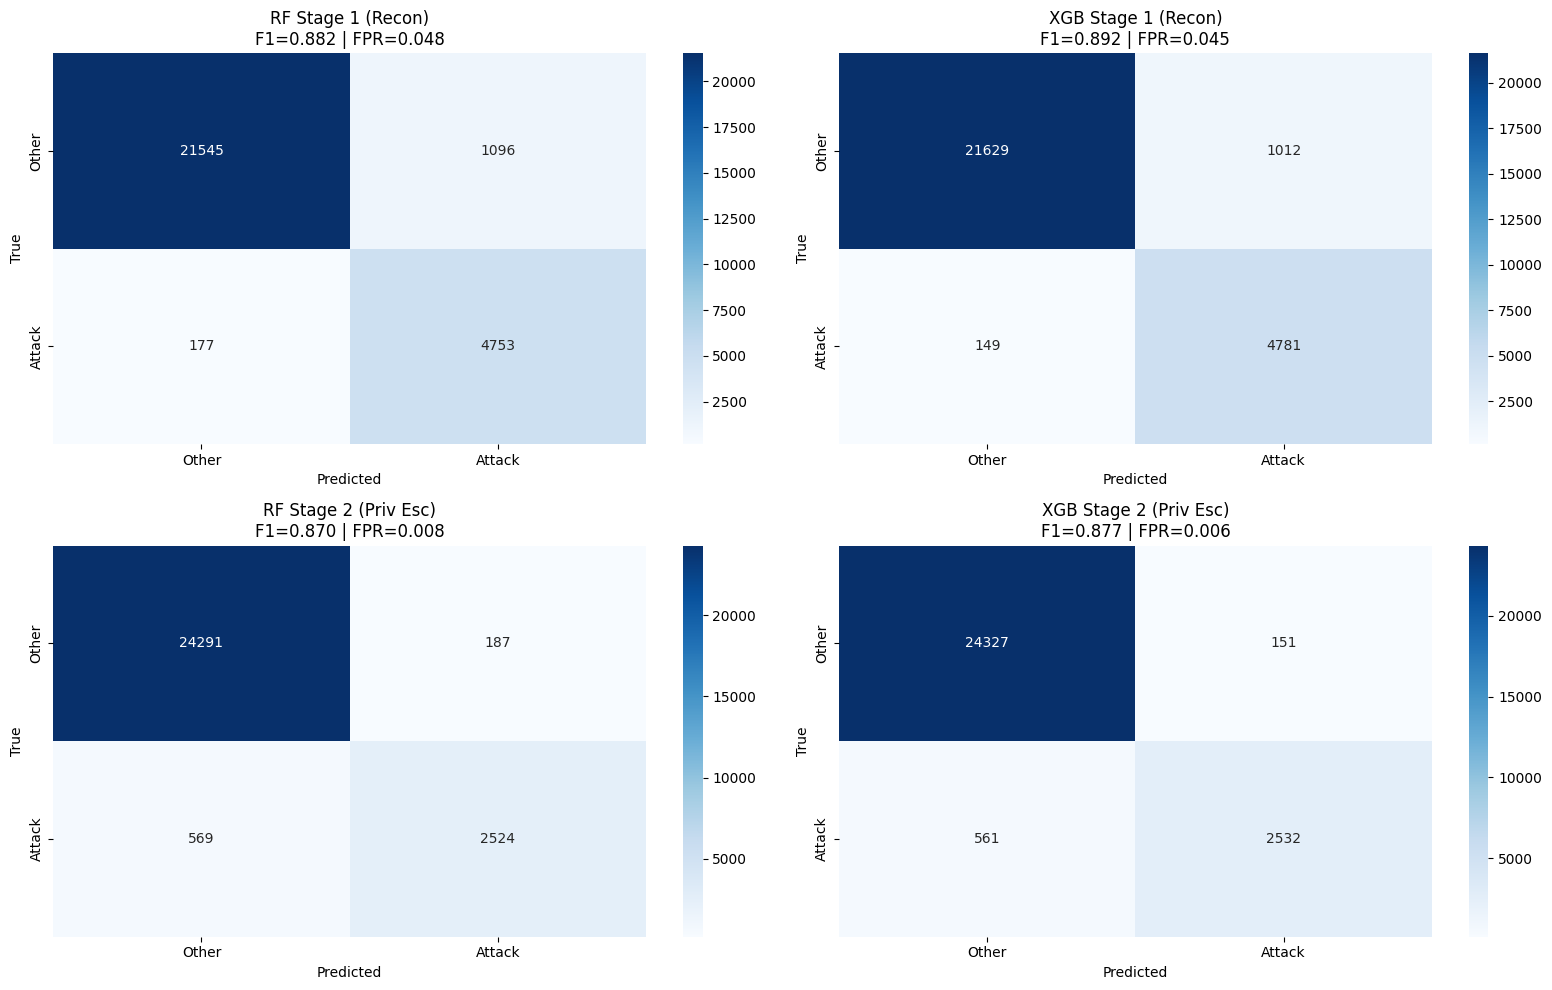

In [131]:
# ═══════════════════════════════════════════════════════════
# Confusion Matrices — Stage 1 & Stage 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models_cm = [
    (axes[0,0], 'RF Stage 1 (Recon)',     rf_s1,  X_te1,     y_te1),
    (axes[0,1], 'XGB Stage 1 (Recon)',    xgb_s1, X_te1_xgb, y_te1),
    (axes[1,0], 'RF Stage 2 (Priv Esc)',  rf_s2,  X_te2,     y_te2),
    (axes[1,1], 'XGB Stage 2 (Priv Esc)', xgb_s2, X_te2_xgb, y_te2),
]

for ax, lbl, model, X_te, y_te in models_cm:
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    fpr = cm[0,1] / (cm[0,0] + cm[0,1])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Other', 'Attack'], yticklabels=['Other', 'Attack'])
    ax.set_title(f"{lbl}\nF1={f1:.3f} | FPR={fpr:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_v4.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

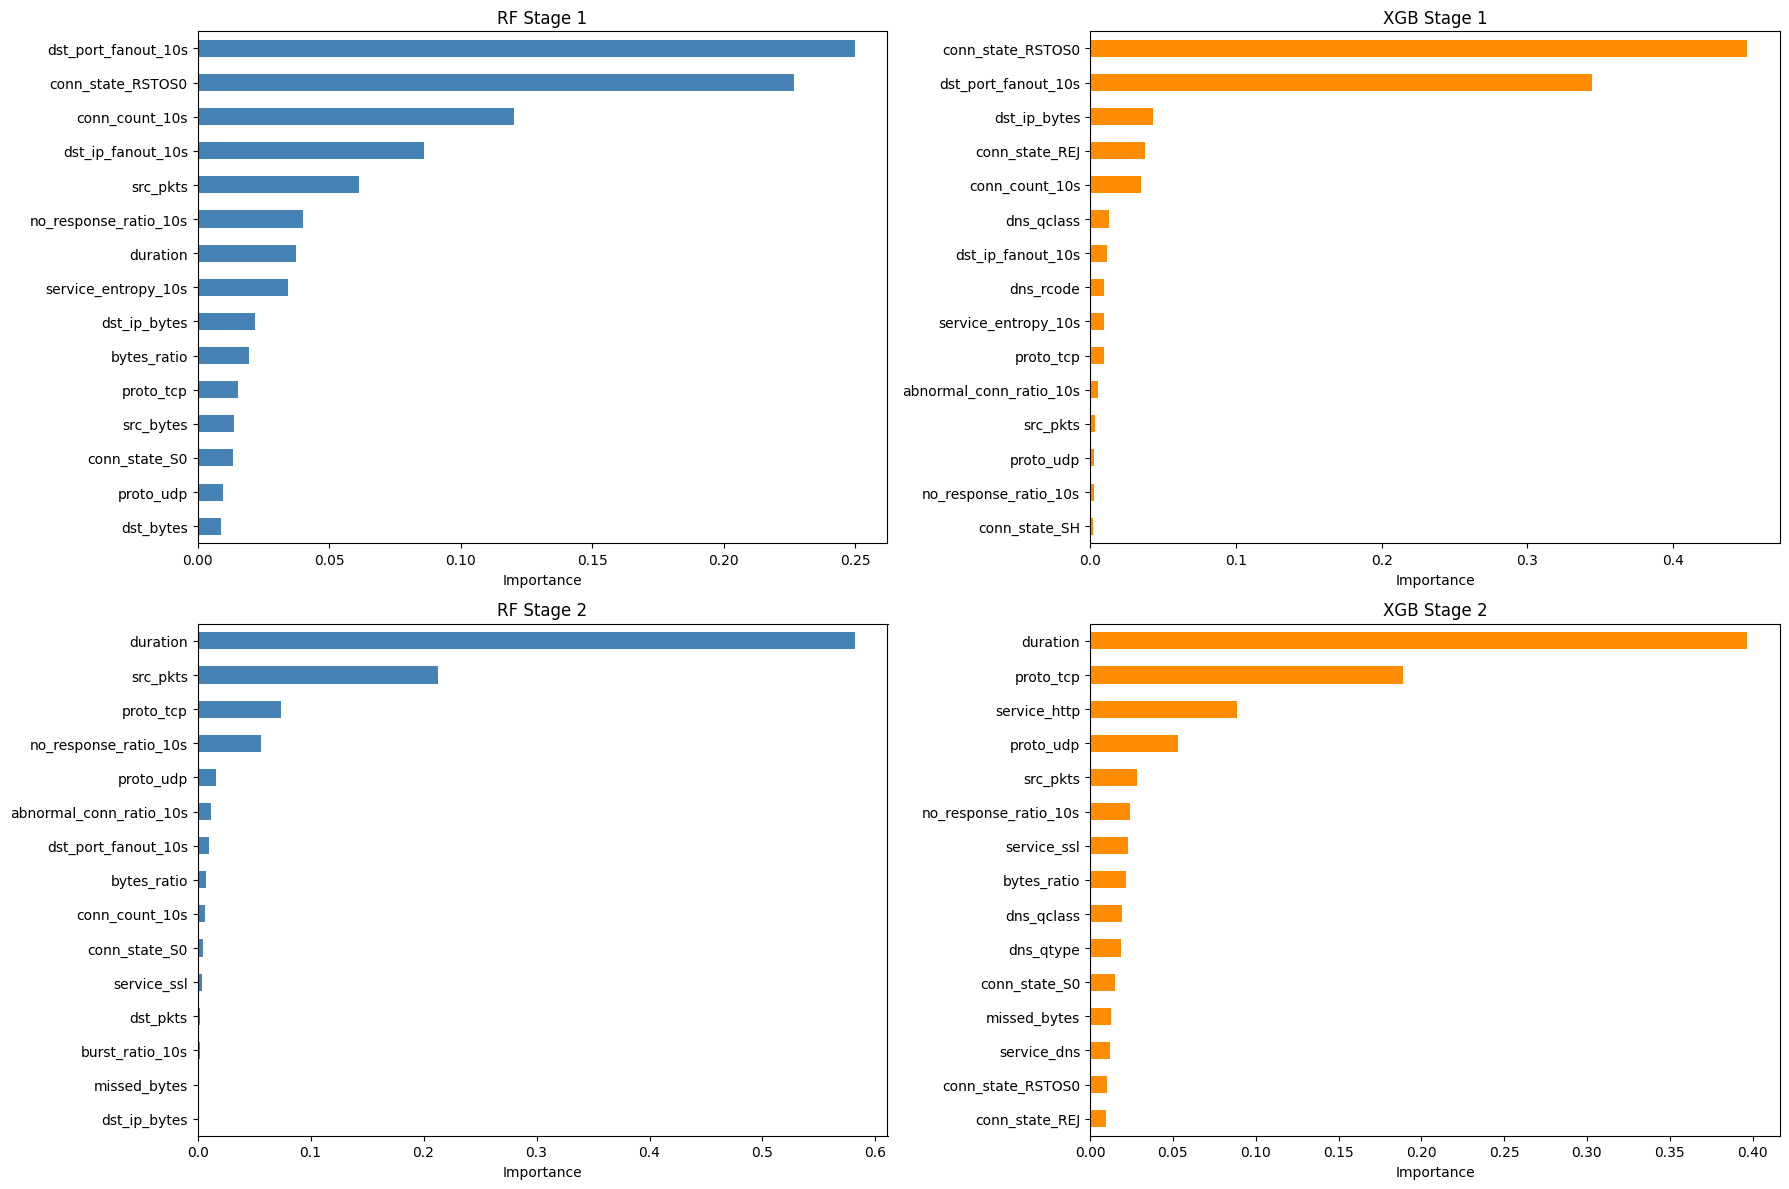

In [132]:
# ═══════════════════════════════════════════════════════════
# Feature Importance — Stage 1 & 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models_fi = [
    (axes[0,0], 'RF Stage 1',  rf_s1,  X_tr1,     'steelblue'),
    (axes[0,1], 'XGB Stage 1', xgb_s1, X_tr1_xgb, 'darkorange'),
    (axes[1,0], 'RF Stage 2',  rf_s2,  X_tr2,     'steelblue'),
    (axes[1,1], 'XGB Stage 2', xgb_s2, X_tr2_xgb, 'darkorange'),
]

for ax, lbl, model, X_tr, color in models_fi:
    imp = pd.Series(model.feature_importances_, index=X_tr.columns).nlargest(15)
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(lbl)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

---
# STAGE 3 PREDICTIONS

In [ ]:
#  LEVEL 2 — entity-level (predictor S3)   ← ini yang dievaluasi
#       build_entity_table(df_past_full, df_future_full)
#           fitur ← agregasi precursor df_past   (stage != 3)
#           label ← keanggotaan S3 di df_future
#       → X3, y3 : 1 baris per dst_ip (90 entity, 9 positif, base rate 10%)
#
#       MODEL : rf3 = RandomForestClassifier(n_estimators=400,
#                     min_samples_leaf=2, class_weight='balanced')
#
#       ┌─ TRAIN ──────────────────────────────────────────────────────────┐
#       │  Data : 4/5 dari (X3, y3)  → ~72 entity, ~7 positif per fold       │
#       │  rf3 di-fit ulang di tiap fold dari nol (cross-validation).         │
#       │  TIDAK ada training final tunggal — model hidup cuma di dalam fold. │
#       └────────────────────────────────────────────────────────────────────┘
#
#       ┌─ EVAL ───────────────────────────────────────────────────────────┐
#       │  Data : 1/5 sisanya  → ~18 entity, ~2 positif per fold            │
#       │  Entity di EVAL tdk pernah ada di TRAIN (entity-disjoint).         │
#       │                                                                    │
#       │  Dua cara baca skor dari fold-fold ini:                            │
#       │   • Headline = RepeatedStratifiedKFold(5×20 = 100 fold)            │
#       │       rata-rata skor antar-fold → 0.730 ± 0.240                    │
#       │       (std besar = jujur; 9 positif bikin per-fold loncat)         │
#       │   • OOF      = cross_val_predict (5-fold ×1)                       │
#       │       tiap entity diskor oleh fold yg tdk ngelatih dia, lalu       │
#       │       dikumpulin → 1 skor atas semua 90 entity:                    │
#       │       OOF ROC-AUC 0.749 | OOF PR-AUC 0.362 (~3.6× base rate)       │
#       │       (OOF ini juga sumber threshold buat confusion matrix)        │
#       │                                                                    │
#       │  F1 (threshold = max-F1 dari OOF PR curve; recall/prec di samping):│
#       │   • RF baseline     thr 0.258 → F1 0.571  (rec 0.67 / prec 0.50)   │
#       │   • RF stage-aware  thr 0.264 → F1 0.545  (rec 0.67 / prec 0.46)   │
#       │   • XGB baseline    thr 0.398 → F1 0.632  (rec 0.67 / prec 0.60)   │
#       │   • XGB stage-aware thr 0.631 → F1 0.533  (rec 0.44 / prec 0.67)   │
#       │   → stage-aware TIDAK nambah F1; RF baseline = headline (0.571).   │
#       │   → CATATAN: F1 sensitif threshold + di N=9 geser 1 entity ≈ 0.1,  │
#       │     jadi selalu baca bareng threshold & recall/precision.          │
#       └────────────────────────────────────────────────────────────────────┘
#
#       KENAPA semua dari (X3,y3) yg sama, tanpa holdout terpisah:
#       9 positif terlalu sedikit buat disisihkan — holdout cuma kebagian
#       ~3 positif (skornya noise) DAN ngabisin positif yang langka. CV
#       muterin peran train/eval ke semua entity → tiap positif kepakai.
#
#  CATATAN: Level 1 & Level 2 split-nya beda tujuan — Level 1 misahin FLOW
#  buat latih detektor; Level 2 misahin ENTITY buat uji predictor. Jangan
#  ketuker: angka headline (0.730) datang dari Level 2.

## 11. Stage 3 - Entity Under Threat

### 11.1 Build Entity Table

In [ ]:
import numpy as np, pandas as pd

def _gini(x):
    """Koefisien Gini dari sebuah distribusi (0 = merata, →1 = timpang).

    KENAPA ADA: dipakai buat fitur `ef_src_gini` — ngukur seberapa terkonsentrasi
    source IP yang ngontak satu entity. Entity yang diserang dari banyak source
    berbeda secara merata (gini rendah) punya profil ancaman beda dari entity yang
    traffic-nya didominasi 1-2 source (gini tinggi, mis. brute-force dari satu host).
    Agregat volume biasa (sum/mean/max) nggak nangkep bentuk distribusi ini, makanya
    butuh ukuran ketimpangan terpisah.

    x : array hitungan flow per source IP (output value_counts()).
    """
    a = np.sort(np.asarray(x, dtype=float))
    if a.size == 0 or a.sum() == 0:            # entity tanpa source / kosong → anggap merata
        return 0.0
    n = a.size; idx = np.arange(1, n + 1)
    # rumus Gini standar atas nilai terurut
    return float((2.0 * (idx * a).sum()) / (n * a.sum()) - (n + 1.0) / n)

NON_FEATURE = ['dst_ip', 'src_ip', 'ts', 'type', 'label', 'stage']

def build_entity_table(df_past, df_future, cohort_mode='loose'):
    """Ubah data FLOW-level jadi tabel ENTITY-level: satu baris per dst_ip at-risk.

    KENAPA FUNGSI INI ADA
    ---------------------
    Dataset mentah = satu baris per flow jaringan. Tapi pertanyaan Stage 3 adalah
    pertanyaan per-ENTITY: "dst_ip mana yang bakal eskalasi ke S3?" — bukan per-flow.
    Fungsi ini ngeringkas semua flow precursor tiap dst_ip jadi SATU baris fitur,
    sehingga model bisa dilatih & dievaluasi di level entity.

    Efek samping penting: karena hasilnya satu baris per entity, cross-validation
    di tabel ini otomatis ENTITY-DISJOINT — nggak ada entity yang bisa nyebrang dari
    train ke test. Itu syarat utama biar evaluasinya jujur.

    TIGA ATURAN YANG BIKIN INI 'PREDIKSI', BUKAN 'DETEKSI'
    ------------------------------------------------------
    1. Cohort at-risk : cuma entity yang udah kena S1/S2 di masa lalu yang dimasukin.
       Niru produksi (predictor S3 cuma jalan utk entity yang udah diflag) + ngilangin
       circularity (model belajar CARA eskalasi, bukan APAKAH diserang).
    2. Fitur PAST-only : diagregasi cuma dari flow precursor (`stage != 3`) di df_past.
       Flow S3 nggak akan pernah masuk vektor fitur (double-guard: past-only + stage!=3).
    3. Label FUTURE-only: 1 kalau entity punya flow S3 di df_future. Fitur (masa lalu)
       dan label (masa depan) dipisah tegas → ada batas before→after asli.

    cohort_mode : 'loose' = kena S1 ATAU S2 ; 'strict' = kena S1 DAN S2.
                  Ini SATU-SATUNYA knob cohort yang sah (BUKAN 'masukin semua IP' —
                  itu cuma numpuk negatif gampang & bikin AUC naik palsu).
    """
    # 1. Tentukan cohort at-risk: entity mana yang punya jejak S1/S2 di masa lalu.
    #    Entity tanpa precursor nggak punya 'titik awal' buat diprediksi eskalasinya.
    gp = df_past.groupby('dst_ip')['stage']
    hit_s1 = gp.apply(lambda s: (s == 1).any())
    hit_s2 = gp.apply(lambda s: (s == 2).any())
    if cohort_mode == 'strict':
        cohort = hit_s1.index[(hit_s1 & hit_s2).values]   # recon DAN exploit
    else:
        cohort = hit_s1.index[(hit_s1 | hit_s2).values]   # recon ATAU exploit

    # 2. Ambil HANYA flow precursor (stage != 3) milik entity cohort, lalu agregasi.
    #    Guard `stage != 3` memastikan flow eskalasi nggak bocor jadi fitur.
    pre = df_past[(df_past['stage'] != 3) & (df_past['dst_ip'].isin(cohort))].copy()
    feat = [c for c in pre.columns
            if c not in NON_FEATURE and pd.api.types.is_numeric_dtype(pre[c])]
    # pisah biner (one-hot) vs kontinu — keduanya diringkas beda cara
    binary = [c for c in feat if set(pre[c].dropna().unique()) <= {0, 1}]
    cont   = [c for c in feat if c not in binary]

    g = pre.groupby('dst_ip')
    parts = []
    if cont:
        # kolom kontinu → 5 statistik ringkasan per entity
        a = g[cont].agg(['sum', 'mean', 'min', 'max', 'std'])
        a.columns = ['_'.join(c) for c in a.columns]
        parts.append(a)
    if binary:
        # kolom biner (mis. conn_state) → jumlah kemunculan = '_count'
        parts.append(g[binary].sum().add_suffix('_count'))
    agg = pd.concat(parts, axis=1)
    agg['flow_count'] = g.size()                          # berapa flow precursor total
    if 'src_ip' in pre.columns:
        # fitur topologi: keragaman & konsentrasi source yang ngontak entity ini
        agg['ef_n_unique_src'] = g['src_ip'].nunique()
        agg['ef_src_gini']     = g['src_ip'].apply(lambda s: _gini(s.value_counts().values))
    agg = agg.round(4).fillna(0.0)

    # 3. Label MURNI dari masa depan: apakah entity ini punya flow S3 di df_future?
    #    Dihitung dari keanggotaan S3 di future — BUKAN dari kolom 'stage' agregat
    #    (yang sekarang konstan 0 di past dan harus diabaikan).
    escal = set(df_future.loc[df_future['stage'] == 3, 'dst_ip'].unique())
    y = agg.index.to_series().isin(escal).astype(int)
    y.name = 'escalates'
    return agg, y

### 11.2 Baseline Model

In [136]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

assert (df_past_full['stage'] == 3).sum() == 0, \
    "df_past masih ada flow S3 — cutoff belum di onset. Re-run timesplit."

X3, y3 = build_entity_table(df_past_full, df_future_full, cohort_mode='loose')
n_pos = int(y3.sum())
print(f"Cohort entities : {len(X3)}")
print(f"Escalators (pos): {n_pos}  (base rate {y3.mean():.1%})")
print(f"Features        : {X3.shape[1]}")

if n_pos < 2:
    print("\n[!] <2 positif — nggak bisa dilatih. Cek cutoff / cohort.")
else:
    n_splits = max(2, min(5, n_pos))
    rf3 = RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=20, random_state=42)
    auc = cross_val_score(rf3, X3.values, y3.values, cv=cv, scoring='roc_auc')
    print(f"\nROC-AUC (headline): {auc.mean():.3f} ± {auc.std():.3f}  "
          f"({len(auc)} folds, {n_splits}-fold ×20)")

    oof = cross_val_predict(rf3, X3.values, y3.values,
                            cv=RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=1, random_state=42),
                            method='predict_proba')[:, 1]
    print(f"OOF ROC-AUC      : {roc_auc_score(y3, oof):.3f}")
    print(f"OOF PR-AUC       : {average_precision_score(y3, oof):.3f}  (base {y3.mean():.3f})")

Cohort entities : 90
Escalators (pos): 9  (base rate 10.0%)
Features        : 112

ROC-AUC (headline): 0.730 ± 0.240  (100 folds, 5-fold ×20)
OOF ROC-AUC      : 0.749
OOF PR-AUC       : 0.362  (base 0.100)


### 11.3 Stage Aware Model & comparison with baseline 

Comparison by ROC-AUC score and paired wilcoxon to see statistical significance

In [144]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from scipy.stats import wilcoxon

# ── 1. OOF proba S1/S2 di flow-level df_past (tiap flow diskor model yg gak ngelatih dia)
feat_cols = [c for c in df_past.columns if c not in ['stage', 'dst_ip']]

def _detector_cfg(stage_num):
    # konfigurasi RF detector yang LO bangun (cell 46 = S1, cell 52 = S2)
    if stage_num == 1:
        return RandomForestClassifier(
            n_estimators=300, max_depth=None,
            class_weight='balanced', random_state=42, n_jobs=-1)
    else:  # stage 2
        return RandomForestClassifier(
            n_estimators=200, max_depth=20, min_samples_split=5, max_features=0.7,
            min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)

def make_oof(stage_num):
    X = df_past[feat_cols].values
    y = (df_past['stage'] == stage_num).astype(int).values
    oof = np.zeros(len(df_past))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for tr, te in skf.split(X, y):
        m = _detector_cfg(stage_num).fit(X[tr], y[tr])   # re-fit per fold → leak-free
        oof[te] = m.predict_proba(X[te])[:, 1]
    return pd.Series(oof, index=df_past.index)

print("Generating OOF S1/S2 proba (bisa makan 1-2 menit)...")
oof_s1, oof_s2 = make_oof(1), make_oof(2)

# ── 2. Agregasi proba per dst_ip, gabung ke X3 → X3_aware
pre = df_past[df_past['dst_ip'].isin(X3.index)].copy()
pre['p_s1'] = oof_s1.reindex(pre.index)
pre['p_s2'] = oof_s2.reindex(pre.index)
g = pre.groupby('dst_ip')
pa = pd.DataFrame(index=X3.index)
for c in ['p_s1', 'p_s2']:
    pa[f'{c}_mean'] = g[c].mean(); pa[f'{c}_max'] = g[c].max(); pa[f'{c}_std'] = g[c].std()
pa['kc_score'] = np.minimum(g['p_s1'].max(), g['p_s2'].max())   # tinggi hanya kalau lihat S1 DAN S2
X3_aware = X3.join(pa.fillna(0.0))
print(f"Baseline feats: {X3.shape[1]} | Stage-aware feats: {X3_aware.shape[1]} (+{X3_aware.shape[1]-X3.shape[1]})")

# ── 3. CV di FOLD YANG SAMA buat dua arm (paired)
rf3 = RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                             class_weight='balanced', random_state=42, n_jobs=-1)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
Xb, Xa, yv = X3.values, X3_aware.values, y3.values
auc_b, auc_a = [], []
for tr, te in cv.split(Xb, yv):
    if len(np.unique(yv[te])) < 2:
        continue
    pb = clone(rf3).fit(Xb[tr], yv[tr]).predict_proba(Xb[te])[:, 1]
    pa_ = clone(rf3).fit(Xa[tr], yv[tr]).predict_proba(Xa[te])[:, 1]
    auc_b.append(roc_auc_score(yv[te], pb))
    auc_a.append(roc_auc_score(yv[te], pa_))
auc_b, auc_a = np.array(auc_b), np.array(auc_a)
diff = auc_a - auc_b

# ── 4. Hasil + paired Wilcoxon
print(f"\nBaseline    ROC-AUC: {auc_b.mean():.3f} ± {auc_b.std():.3f}")
print(f"Stage-aware ROC-AUC: {auc_a.mean():.3f} ± {auc_a.std():.3f}")
print(f"Delta (aware-base) : {diff.mean():+.4f}  ({len(diff)} paired folds)")
if np.allclose(diff, 0):
    print("Wilcoxon: semua delta = 0 → tidak ada perbedaan (p = 1.0)")
else:
    stat, p = wilcoxon(auc_a, auc_b)
    verdict = "SIGNIFIKAN" if p < 0.05 else "TIDAK signifikan"
    print(f"Paired Wilcoxon p  : {p:.3f}  → lift {verdict} (alpha 0.05)")

Generating OOF S1/S2 proba (bisa makan 1-2 menit)...
Baseline feats: 112 | Stage-aware feats: 119 (+7)

Baseline    ROC-AUC: 0.730 ± 0.240
Stage-aware ROC-AUC: 0.725 ± 0.218
Delta (aware-base) : -0.0054  (100 paired folds)
Paired Wilcoxon p  : 0.452  → lift TIDAK signifikan (alpha 0.05)


### 11.4 Confusion Matrices & Feature Importance

Feature importance using feature permutation method


=== baseline | thr 0.258 | F1 0.571 ===
              precision    recall  f1-score   support

        Safe       0.96      0.93      0.94        81
   Escalates       0.50      0.67      0.57         9

    accuracy                           0.90        90
   macro avg       0.73      0.80      0.76        90
weighted avg       0.92      0.90      0.91        90

Top 8 — baseline:
duration_sum      0.0
duration_mean     0.0
duration_min      0.0
duration_max      0.0
duration_std      0.0
src_bytes_sum     0.0
src_bytes_mean    0.0
src_bytes_min     0.0

=== stage-aware | thr 0.264 | F1 0.545 ===
              precision    recall  f1-score   support

        Safe       0.96      0.91      0.94        81
   Escalates       0.46      0.67      0.55         9

    accuracy                           0.89        90
   macro avg       0.71      0.79      0.74        90
weighted avg       0.91      0.89      0.90        90

Top 8 — stage-aware:
duration_sum      0.0
duration_mean     0.0
du

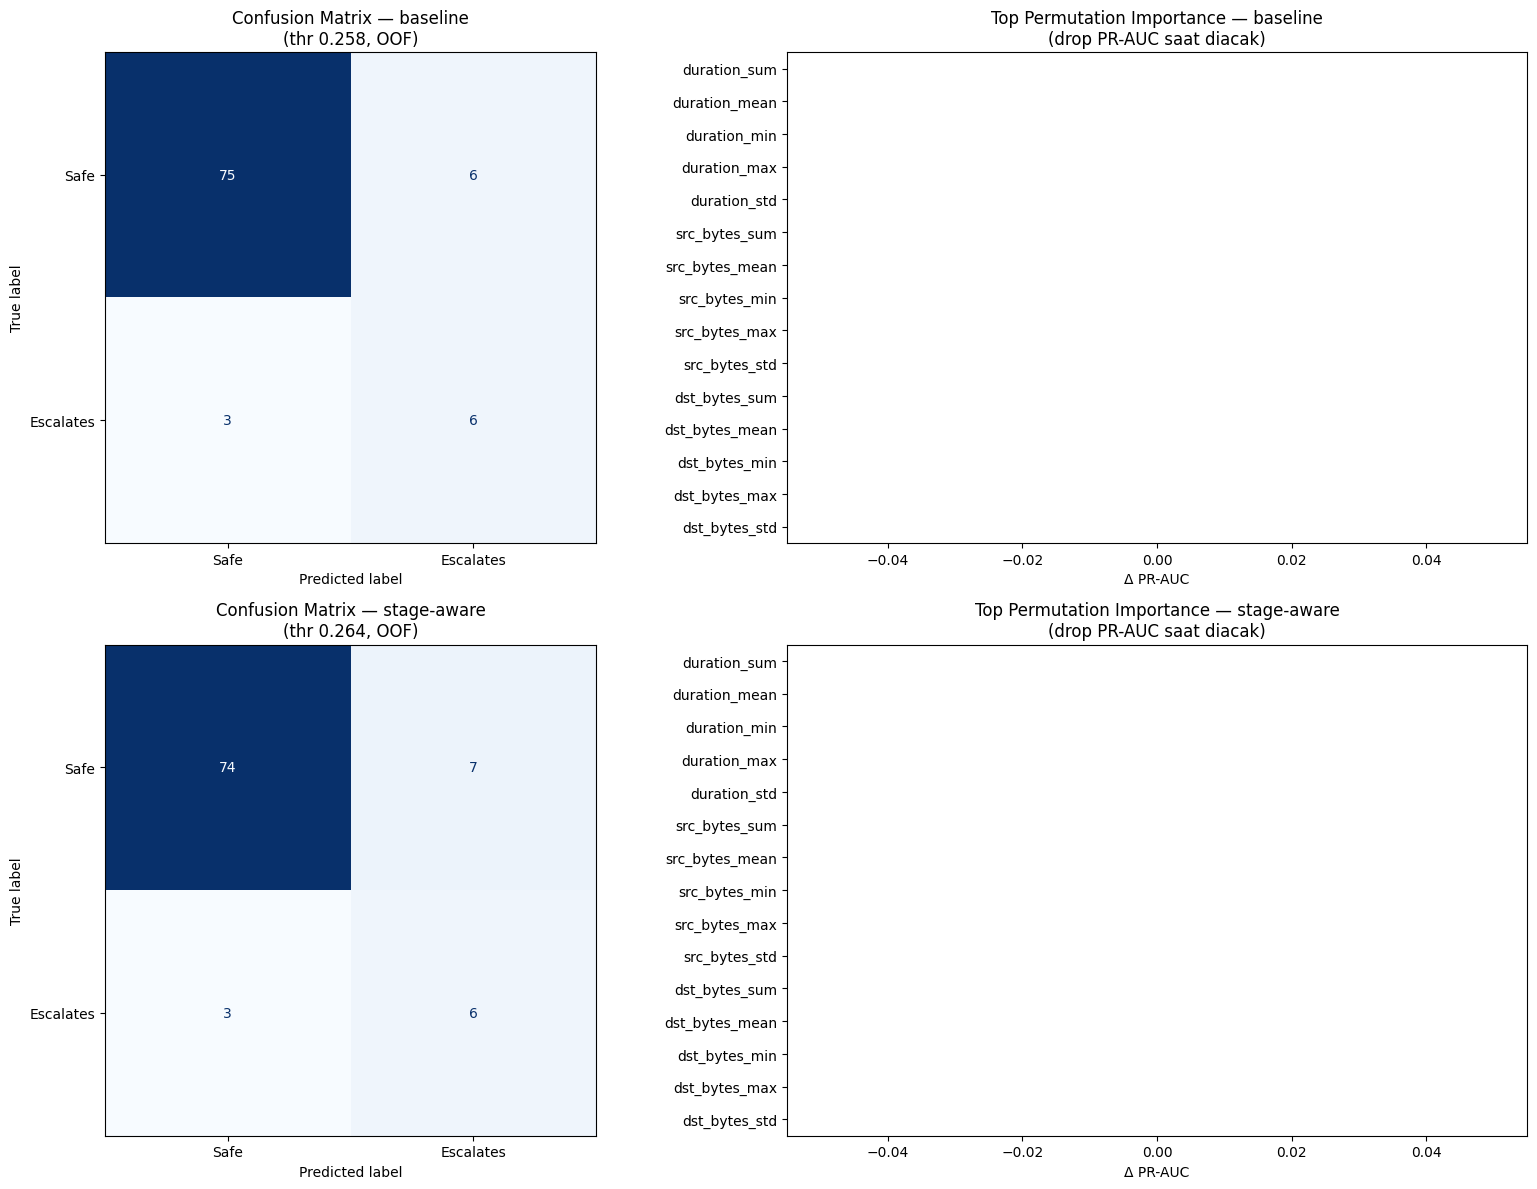

In [145]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, f1_score, classification_report)
from sklearn.inspection import permutation_importance

def inspect(X_use, arm, ax_cm, ax_imp):
    Xv, yv = X_use.values, y3.values
    oof = cross_val_predict(
        clone(rf3), Xv, yv,
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42),
        method='predict_proba')[:, 1]

    prec, rec, thr = precision_recall_curve(yv, oof)
    f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
    t = thr[f1s.argmax()]
    y_pred = (oof >= t).astype(int)
    print(f"\n=== {arm} | thr {t:.3f} | F1 {f1_score(yv,y_pred):.3f} ===")
    print(classification_report(yv, y_pred, target_names=['Safe','Escalates'], zero_division=0))

    cm = confusion_matrix(yv, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Safe','Escalates']).plot(
        ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f'Confusion Matrix — {arm}\n(thr {t:.3f}, OOF)')

    # PR-AUC scoring (sensitif di imbalanced), buang fitur nol-semua biar plot informatif
    rf_full = clone(rf3).fit(Xv, yv)
    perm = permutation_importance(rf_full, Xv, yv, n_repeats=30,
                                  random_state=42, scoring='average_precision') 
    imp = pd.Series(perm.importances_mean, index=X_use.columns).sort_values(ascending=False)
    top = imp[imp.abs() > 1e-4].head(15)
    if len(top) == 0:
        top = imp.head(15)   # fallback kalau beneran semua ~0
    top[::-1].plot.barh(ax=ax_imp, color='steelblue')
    ax_imp.set_title(f'Top Permutation Importance — {arm}\n(drop PR-AUC saat diacak)')
    ax_imp.set_xlabel('Δ PR-AUC')
    print(f"Top 8 — {arm}:")
    print(imp.head(8).round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
inspect(X3,        "baseline",    axes[0,0], axes[0,1])
inspect(X3_aware,  "stage-aware", axes[1,0], axes[1,1])
plt.tight_layout(); plt.show()

## 12. Stage 3 - Entity Under Threat Model Exploration 

Exploration of feature engineering and meta learner model

### 12.1 Feature Engineering Comparison

In [146]:
# ── EXPLORATORY arm: kill-chain encoding (alert-count, CKC multiplier, threat density)
# CATATAN: di N=9 ini nggak bisa diverifikasi naik/turun. Baseline tetap headline.
from scipy.stats import wilcoxon
from sklearn.base import clone

ALERT_THR = 0.70
pre = df_past[df_past['dst_ip'].isin(X3.index)].copy()
pre['p_s1'] = oof_s1.reindex(pre.index)
pre['p_s2'] = oof_s2.reindex(pre.index)
g = pre.groupby('dst_ip')

ckc = pd.DataFrame(index=X3.index)
ckc['s1_alert_high']      = g['p_s1'].apply(lambda s: (s > ALERT_THR).sum())
ckc['s2_alert_high']      = g['p_s2'].apply(lambda s: (s > ALERT_THR).sum())
ckc['ckc_interaction_max'] = g['p_s1'].max() * g['p_s2'].max()
# threat density = total proba serangan / total flow (ganti g.size() ke kolom bytes kalau mau per-traffic)
ckc['threat_density']     = (g['p_s1'].sum() + g['p_s2'].sum()) / (g.size() + 1e-9)
ckc = ckc.fillna(0.0)

X3_ckc = X3.join(ckc)
print(f"Baseline feats: {X3.shape[1]} | CKC feats: {X3_ckc.shape[1]} (+{X3_ckc.shape[1]-X3.shape[1]})")

Xb, Xc, yv = X3.values, X3_ckc.values, y3.values
auc_b, auc_c = [], []
for tr, te in cv.split(Xb, yv):
    if len(np.unique(yv[te])) < 2:
        continue
    pb = clone(rf3).fit(Xb[tr], yv[tr]).predict_proba(Xb[te])[:, 1]
    pc = clone(rf3).fit(Xc[tr], yv[tr]).predict_proba(Xc[te])[:, 1]
    auc_b.append(roc_auc_score(yv[te], pb))
    auc_c.append(roc_auc_score(yv[te], pc))
auc_b, auc_c = np.array(auc_b), np.array(auc_c)
diff = auc_c - auc_b

print(f"\nBaseline ROC-AUC: {auc_b.mean():.3f} ± {auc_b.std():.3f}")
print(f"CKC      ROC-AUC: {auc_c.mean():.3f} ± {auc_c.std():.3f}")
print(f"Delta (ckc-base): {diff.mean():+.4f}  ({len(diff)} paired folds)")
if np.allclose(diff, 0):
    print("Wilcoxon: semua delta = 0 (p = 1.0)")
else:
    stat, p = wilcoxon(auc_c, auc_b)
    if p >= 0.05:           verdict = "TIDAK signifikan (ckc ≈ base)"
    elif diff.mean() > 0:   verdict = "ckc > base (signifikan)"
    else:                   verdict = "ckc < base (signifikan) — malah lebih jelek"
    print(f"Paired Wilcoxon p: {p:.3f}  → {verdict} (alpha 0.05)")
    print("CAVEAT: 100 fold = 20x ulang 5-fold atas 90 entity yg sama → tidak independen, p anti-conservative.")

Baseline feats: 112 | CKC feats: 116 (+4)

Baseline ROC-AUC: 0.730 ± 0.240
CKC      ROC-AUC: 0.720 ± 0.233
Delta (ckc-base): -0.0101  (100 paired folds)
Paired Wilcoxon p: 0.122  → TIDAK signifikan (ckc ≈ base) (alpha 0.05)
CAVEAT: 100 fold = 20x ulang 5-fold atas 90 entity yg sama → tidak independen, p anti-conservative.


### 12.2 XGBoost Metalearner

In [142]:
# ── CROSS-MODEL CHECK: XGBoost, baseline & stage-aware (paired, fold sama)
# Tujuan: konfirmasi 0.73 bukan artefak RF. Param FIXED & regularized utk N=9 — BUKAN tuning.
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import wilcoxon
from sklearn.base import clone
import numpy as np

n_pos   = int(y3.sum())
n_splits = max(2, min(5, n_pos))
spw     = (len(y3) - n_pos) / n_pos          # scale_pos_weight = neg/pos (≈9)

xgb3 = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
    reg_lambda=1.0, scale_pos_weight=spw,
    eval_metric='logloss', random_state=42, n_jobs=-1,
)

cv      = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=20, random_state=42)
cv_oof  = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=1,  random_state=42)

def report(name, X):
    auc = cross_val_score(xgb3, X.values, y3.values, cv=cv, scoring='roc_auc')
    oof = cross_val_predict(xgb3, X.values, y3.values, cv=cv_oof, method='predict_proba')[:, 1]
    print(f"  {name:<12} headline {auc.mean():.3f} ± {auc.std():.3f} | "
          f"OOF ROC {roc_auc_score(y3, oof):.3f} | OOF PR {average_precision_score(y3, oof):.3f}")
    return auc

print(f"XGBoost (scale_pos_weight={spw:.1f}) — {n_splits}-fold ×20\n")
auc_b = report("baseline",    X3)
auc_a = report("stage-aware", X3_aware)

# ── paired baseline vs stage-aware (fold identik)
Xb, Xa, yv = X3.values, X3_aware.values, y3.values
pb_list, pa_list = [], []
for tr, te in cv.split(Xb, yv):
    if len(np.unique(yv[te])) < 2:
        continue
    pb_list.append(roc_auc_score(yv[te], clone(xgb3).fit(Xb[tr], yv[tr]).predict_proba(Xb[te])[:, 1]))
    pa_list.append(roc_auc_score(yv[te], clone(xgb3).fit(Xa[tr], yv[tr]).predict_proba(Xa[te])[:, 1]))
pb_arr, pa_arr = np.array(pb_list), np.array(pa_list)
diff = pa_arr - pb_arr

print(f"\nPaired (XGB): delta (aware-base) {diff.mean():+.4f}  ({len(diff)} folds)")
if np.allclose(diff, 0):
    print("Wilcoxon: semua delta = 0 (p = 1.0)")
else:
    stat, p = wilcoxon(pa_arr, pb_arr)
    if p >= 0.05:           verdict = "TIDAK signifikan (aware ≈ base)"
    elif diff.mean() > 0:   verdict = "aware > base (signifikan)"
    else:                   verdict = "aware < base (signifikan) — malah lebih jelek"
    print(f"Wilcoxon p: {p:.3f}  → {verdict} (alpha 0.05)")
    print("CAVEAT: 100 fold = 20x ulang 5-fold atas entity yg sama → tidak independen, p anti-conservative.")

print(f"\n>> Cross-model: RF baseline ~0.730 vs XGB baseline {auc_b.mean():.3f} "
      f"→ {'konsisten (bukan artefak RF)' if abs(auc_b.mean()-0.730) < auc_b.std() else 'beda > 1 std, cek'}")

XGBoost (scale_pos_weight=9.0) — 5-fold ×20

  baseline     headline 0.756 ± 0.246 | OOF ROC 0.763 | OOF PR 0.600
  stage-aware  headline 0.750 ± 0.244 | OOF ROC 0.761 | OOF PR 0.560

Paired (XGB): delta (aware-base) -0.0063  (100 folds)
Wilcoxon p: 0.087  → TIDAK signifikan (aware ≈ base) (alpha 0.05)
CAVEAT: 100 fold = 20x ulang 5-fold atas entity yg sama → tidak independen, p anti-conservative.

>> Cross-model: RF baseline ~0.730 vs XGB baseline 0.756 → konsisten (bukan artefak RF)


### 12.3 XGBoost Metalearner Confusion Matrices & Feature Importance

Feature importance by permutation


=== baseline (XGB) | thr 0.398 | F1 0.632 ===
              precision    recall  f1-score   support

        Safe       0.96      0.95      0.96        81
   Escalates       0.60      0.67      0.63         9

    accuracy                           0.92        90
   macro avg       0.78      0.81      0.79        90
weighted avg       0.93      0.92      0.92        90

Top 8 — baseline:
ef_n_unique_src             0.0528
dst_bytes_std               0.0489
flow_count                  0.0473
service_entropy_10s_mean    0.0411
src_pkts_std                0.0325
duration_max                0.0318
duration_mean               0.0242
src_bytes_std               0.0222

=== stage-aware (XGB) | thr 0.631 | F1 0.533 ===
              precision    recall  f1-score   support

        Safe       0.94      0.98      0.96        81
   Escalates       0.67      0.44      0.53         9

    accuracy                           0.92        90
   macro avg       0.80      0.71      0.75        90
weight

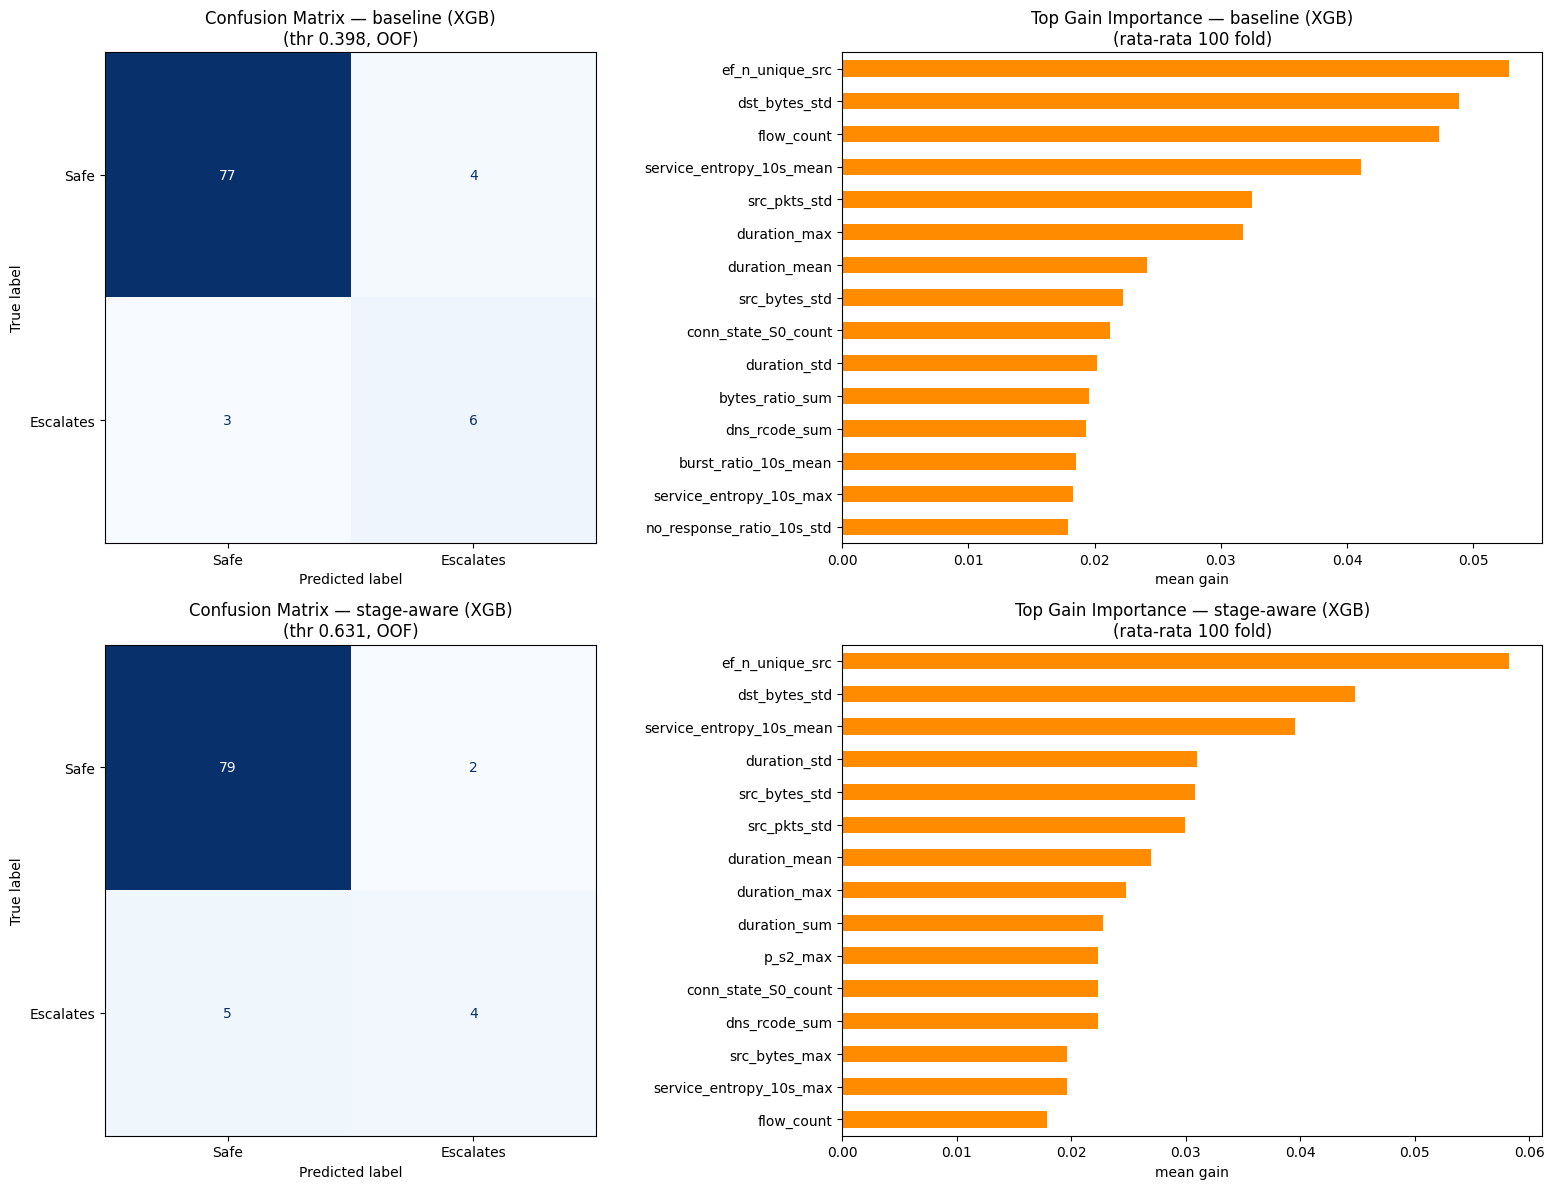

In [143]:
# ── FINAL: confusion matrix + feature importance (XGB), baseline & stage-aware
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, f1_score, classification_report)
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_predict
from sklearn.base import clone

cv      = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
cv_oof  = RepeatedStratifiedKFold(n_splits=5, n_repeats=1,  random_state=42)

def inspect_xgb(X_use, arm, ax_cm, ax_imp):
    Xv, yv = X_use.values, y3.values

    # confusion matrix dari OOF, threshold = max-F1 di PR curve (sama persis kayak RF)
    oof = cross_val_predict(clone(xgb3), Xv, yv, cv=cv_oof, method='predict_proba')[:, 1]
    prec, rec, thr = precision_recall_curve(yv, oof)
    f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
    t = thr[f1s.argmax()]
    y_pred = (oof >= t).astype(int)
    print(f"\n=== {arm} (XGB) | thr {t:.3f} | F1 {f1_score(yv,y_pred):.3f} ===")
    print(classification_report(yv, y_pred, target_names=['Safe','Escalates'], zero_division=0))

    cm = confusion_matrix(yv, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Safe','Escalates']).plot(
        ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f'Confusion Matrix — {arm} (XGB)\n(thr {t:.3f}, OOF)')

    # gain importance dirata-rata across 100 fold (stabil) — bukan single-fit
    m_imp = clone(xgb3).set_params(importance_type='gain')
    imps = [clone(m_imp).fit(Xv[tr], yv[tr]).feature_importances_
            for tr, te in cv.split(Xv, yv) if len(np.unique(yv[te])) >= 2]
    imp = pd.Series(np.mean(imps, axis=0), index=X_use.columns).sort_values(ascending=False)
    top = imp[imp > 0].head(15)
    top[::-1].plot.barh(ax=ax_imp, color='darkorange')
    ax_imp.set_title(f'Top Gain Importance — {arm} (XGB)\n(rata-rata 100 fold)')
    ax_imp.set_xlabel('mean gain')
    print(f"Top 8 — {arm}:")
    print(imp.head(8).round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
inspect_xgb(X3,       "baseline",    axes[0,0], axes[0,1])
inspect_xgb(X3_aware, "stage-aware", axes[1,0], axes[1,1])
plt.tight_layout(); plt.show()

## Direct/Baseline (Old)


In [137]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — ENTITY UNDER THREAT MODEL (RandomForest + RandomizedSearchCV)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns   
import numpy as np

# ── 1. Sanity check ───────────────────────────────────────────────────────────
print(f"X_tr3_base: {X_tr3_base.shape}  |  y_tr3_base positives: {int(y_tr3_base.sum())} / {len(y_tr3_base)}")
print(f"X_te3_base: {X_te3_base.shape}  |  y_te3_base positives: {int(y_te3_base.sum())} / {len(y_te3_base)}")
assert y_tr3_base.sum() > 0, "No positives in training — check prepare_Xy_pred fix"
assert y_te3_base.sum() > 0, "No positives in test — check prepare_Xy_pred fix"

# ── 2. Class imbalance ratio (used for scale_pos_weight guidance) ─────────────
neg_tr, pos_tr = (y_tr3_base == 0).sum(), (y_tr3_base == 1).sum()
imbalance_ratio = neg_tr / pos_tr
print(f"\nClass ratio (neg:pos) in train = {imbalance_ratio:.1f}:1")

# ── 3. Hyperparameter search space ───────────────────────────────────────────
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'class_weight'     : ['balanced', 'balanced_subsample',
                          {0: 1, 1: int(imbalance_ratio)},
                          {0: 1, 1: int(imbalance_ratio * 1.5)}],
}

# Stratified CV — critical for imbalanced entity-level data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',          # optimise for minority-class F1
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("\nRunning RandomizedSearchCV (40 iterations × 5-fold CV)...")
search.fit(X_tr3_base, y_tr3_base)

print(f"\nBest CV F1  : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")

rf_s3 = search.best_estimator_

# ── 4. Default threshold predictions ──────────────────────────────────────────
y_proba_s3_base = rf_s3.predict_proba(X_te3_base)[:, 1]
y_pred_s3_base  = rf_s3.predict(X_te3_base)

# ── 5. Optimal threshold via PR curve ────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te3_base, y_proba_s3_base)
f1_arr  = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-8)
best_idx   = np.argmax(f1_arr)
best_thresh = thresh_arr[best_idx] if best_idx < len(thresh_arr) else 0.5

print(f"\nOptimal threshold: {best_thresh:.4f}  (F1={f1_arr[best_idx]:.4f})")
y_pred_s3_opt_base = (y_proba_s3_base >= best_thresh).astype(int)

# ── 6. Evaluation helper (reuses notebook style) ─────────────────────────────
def eval_s3(y_true, y_pred, label):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(classification_report(y_true, y_pred,
          target_names=['Safe entity', 'Under threat'], zero_division=0))
    return {'f1': f1, 'precision': prec, 'recall': rec, 'fpr': fpr, 'cm': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

results_s3_default_base = eval_s3(y_te3_base, y_pred_s3_base,  "Stage 3 — default threshold (0.50)")
results_s3_opt_base     = eval_s3(y_te3_base, y_pred_s3_opt_base,  f"Stage 3 — optimal threshold ({best_thresh:.4f})")

# ── 7. Figures ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 7a. Confusion matrix — default threshold
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(results_s3_default_base['cm'], annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax1.set_title(f"Confusion matrix (t=0.50)\nF1={results_s3_default_base['f1']:.3f} | FPR={results_s3_default_base['fpr']:.3f}")
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

# 7b. Confusion matrix — optimal threshold
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(results_s3_opt_base['cm'], annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax2.set_title(f"Confusion matrix (t={best_thresh:.3f})\nF1={results_s3_opt_base['f1']:.3f} | FPR={results_s3_opt_base['fpr']:.3f}")
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

# 7c. PR curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_arr, prec_arr, 'b-', lw=2, label='PR curve')
ax3.scatter(rec_arr[best_idx], prec_arr[best_idx],
            color='red', s=100, zorder=5, label=f'Best t={best_thresh:.3f}')
pr_auc = auc(rec_arr, prec_arr)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall curve\nAUC-PR={pr_auc:.4f}')
ax3.legend(); ax3.grid(True, alpha=0.3)

# 7d. F1 vs threshold
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(thresh_arr, f1_arr[:-1], 'g-', lw=2)
ax4.axvline(x=best_thresh, color='r', ls='--', alpha=0.8, label=f't={best_thresh:.3f}')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('F1')
ax4.set_title('F1 vs threshold'); ax4.legend(); ax4.grid(True, alpha=0.3)

# 7e. ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_te3_base, y_proba_s3_base)
roc_auc_score = auc(fpr_roc, tpr_roc)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AUC={roc_auc_score:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.set_title('ROC curve'); ax5.legend(); ax5.grid(True, alpha=0.3)

# 7f. Feature importance (top 20)
ax6 = fig.add_subplot(gs[1, 2])
feat_imp = pd.Series(rf_s3.feature_importances_, index=X_tr3_base.columns).nlargest(20)
feat_imp.plot(kind='barh', ax=ax6, color='steelblue')
ax6.set_title('Top 20 feature importances')
ax6.set_xlabel('Importance'); ax6.invert_yaxis()

plt.suptitle('Stage 3 — Entity Under Threat Model (RandomForest)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('stage3_entity_underthreat_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STAGE 3 SUMMARY")
print("="*60)
print(f"  Best hyperparams : {search.best_params_}")
print(f"  CV F1 (train)    : {search.best_score_:.4f}")
print(f"  Test F1 (t=0.50) : {results_s3_default_base['f1']:.4f}")
print(f"  Test F1 (t={best_thresh:.3f}) : {results_s3_opt_base['f1']:.4f}")
print(f"  AUC-ROC          : {roc_auc_score:.4f}")
print(f"  AUC-PR           : {pr_auc:.4f}")
print(f"  Test entities    : {len(y_te3_base)} | Threat: {int(y_te3_base.sum())} | Safe: {int((y_te3_base==0).sum())}")


X_tr3_base: (349, 208)  |  y_tr3_base positives: 0 / 349
X_te3_base: (102, 208)  |  y_te3_base positives: 13 / 102


AssertionError: No positives in training — check prepare_Xy_pred fix